## Introduction and Lesson Overview

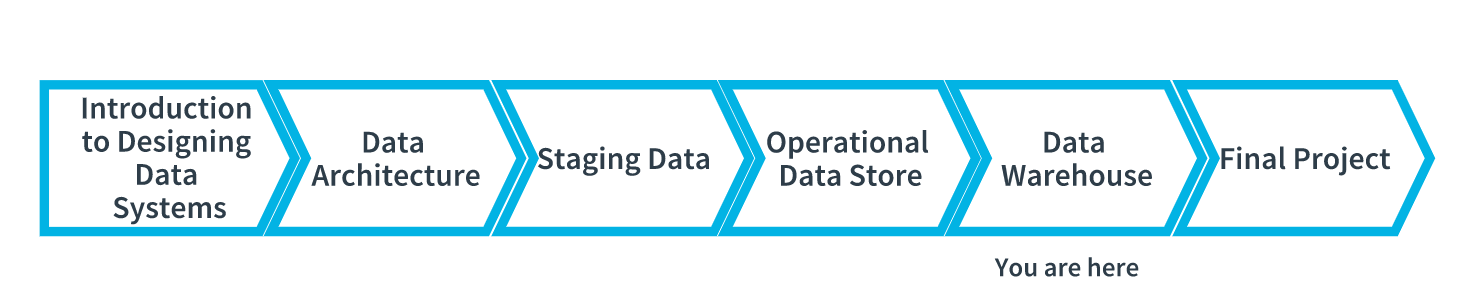

https://www.youtube.com/watch?v=UjwiSE1zCZQ

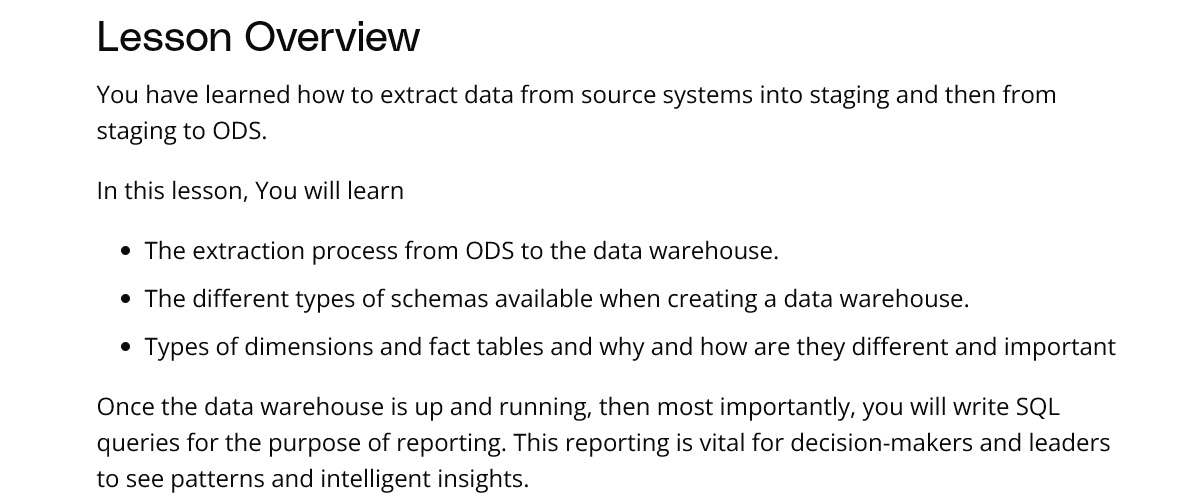

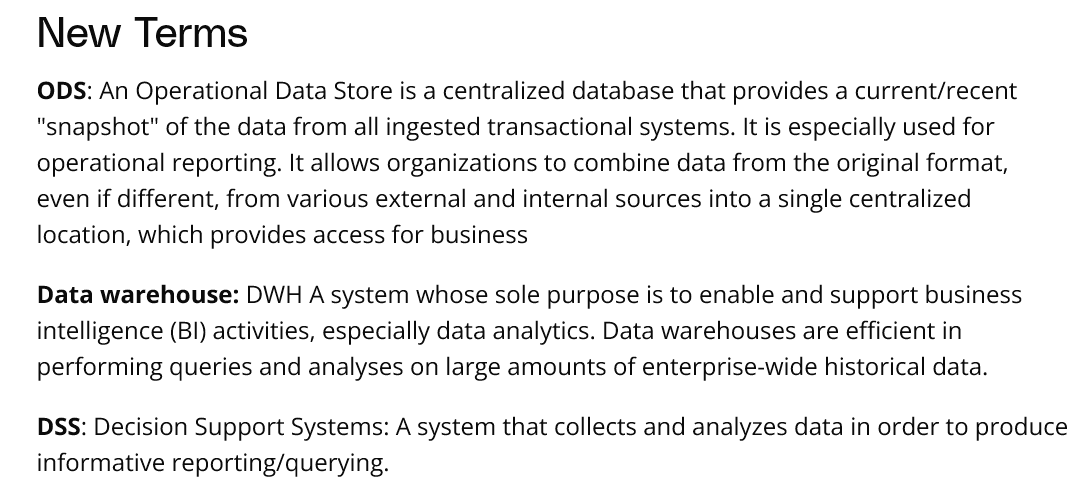

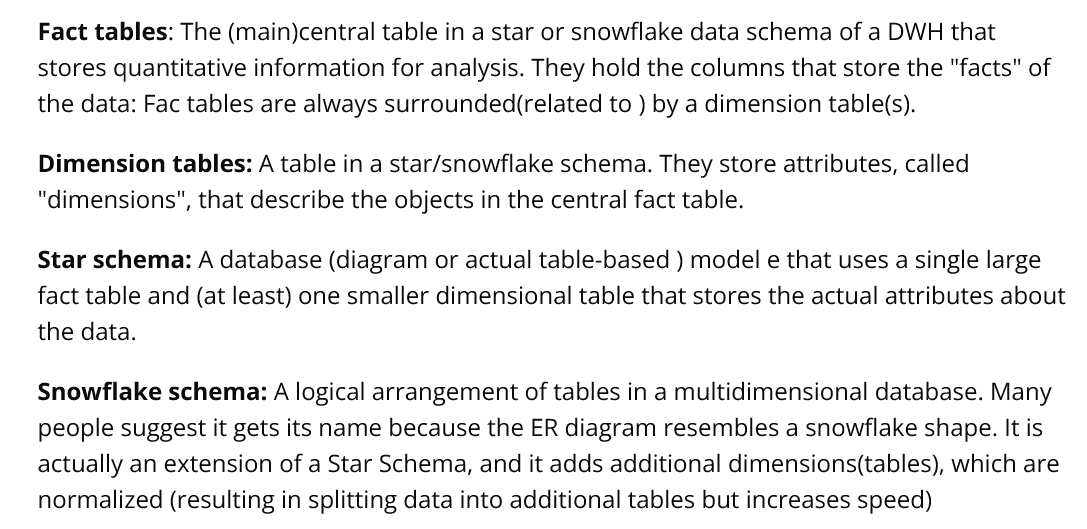

## What is a Data Warehouse?

https://www.youtube.com/watch?v=1bm4HbYztZo

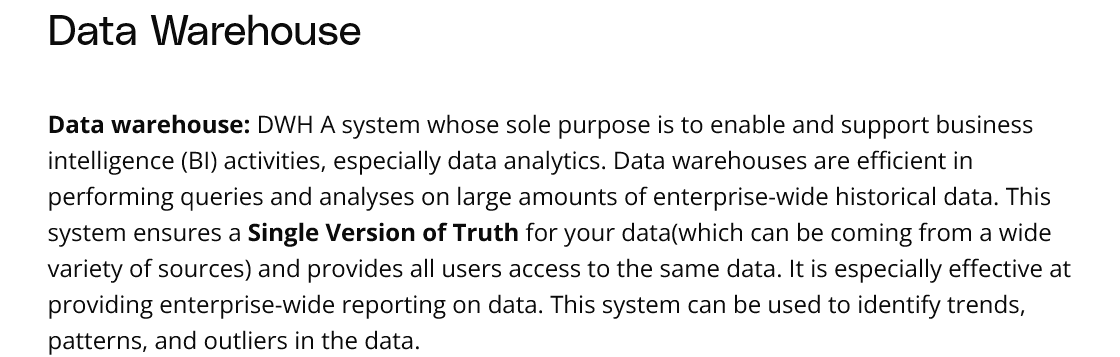

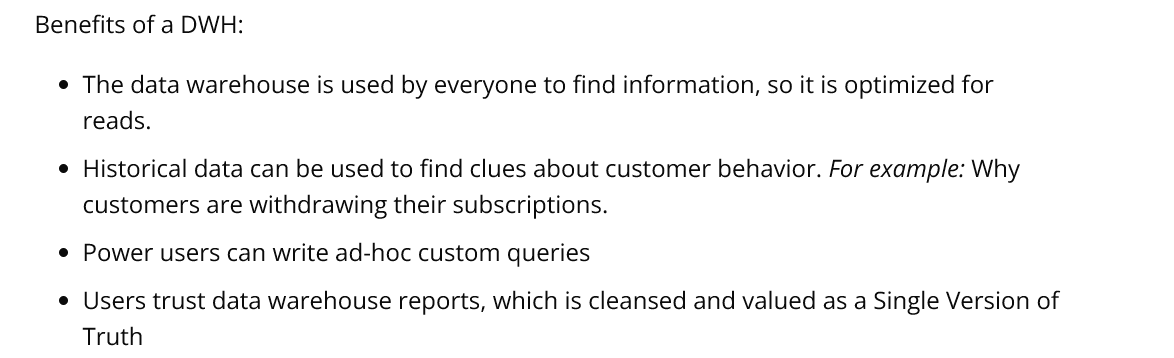

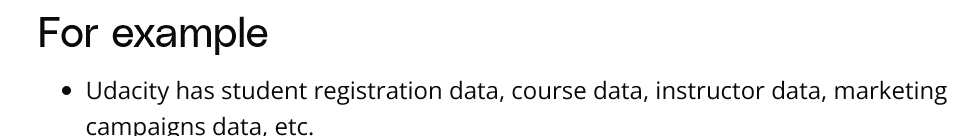

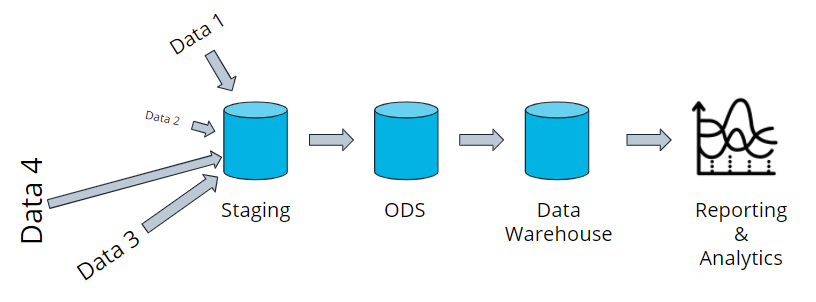

## Typical Data Architecture

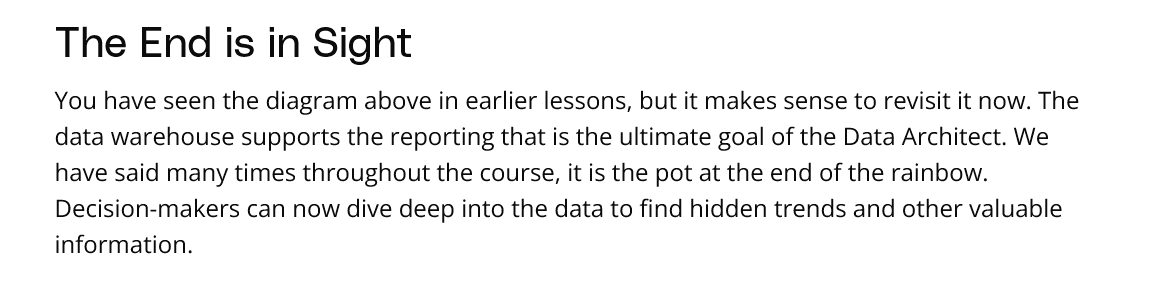

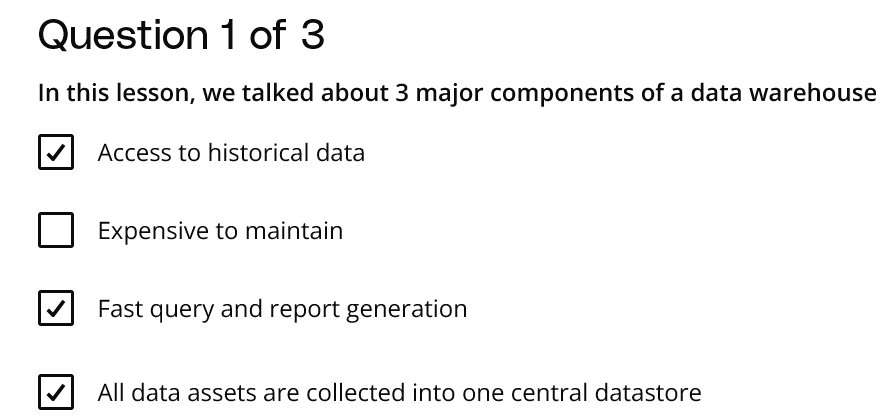

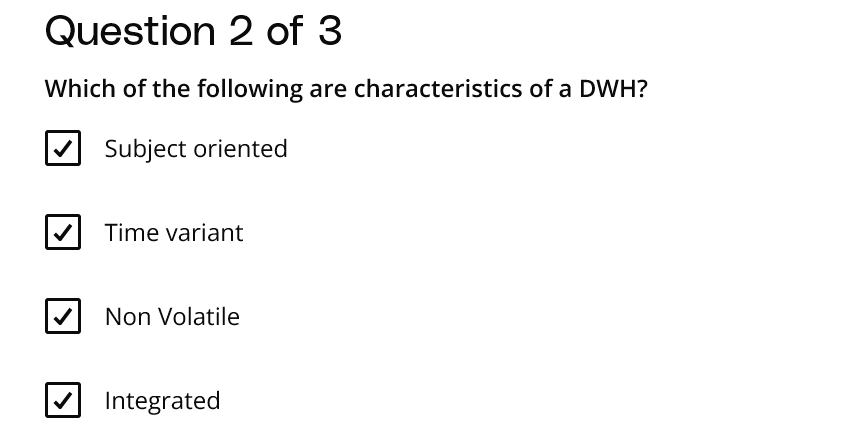

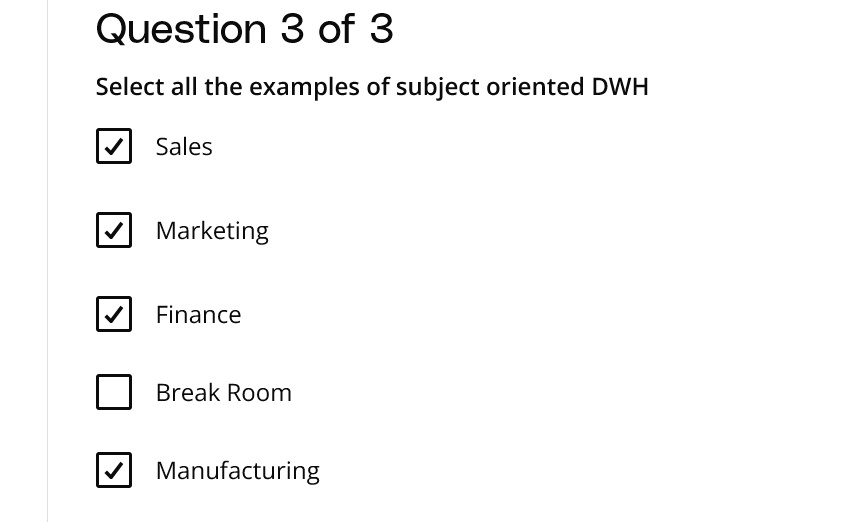

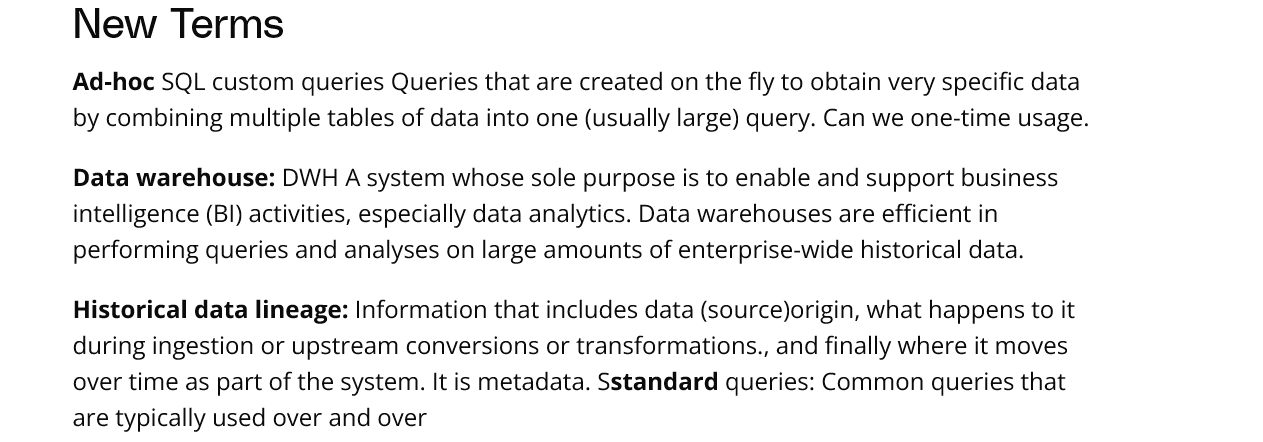

## Why Data Warehousing Matters?

https://www.youtube.com/watch?v=Seclp805ZJ8

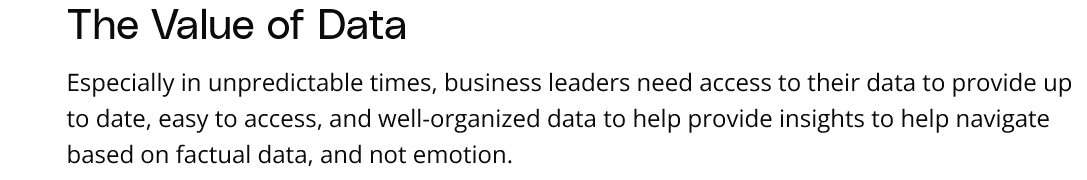

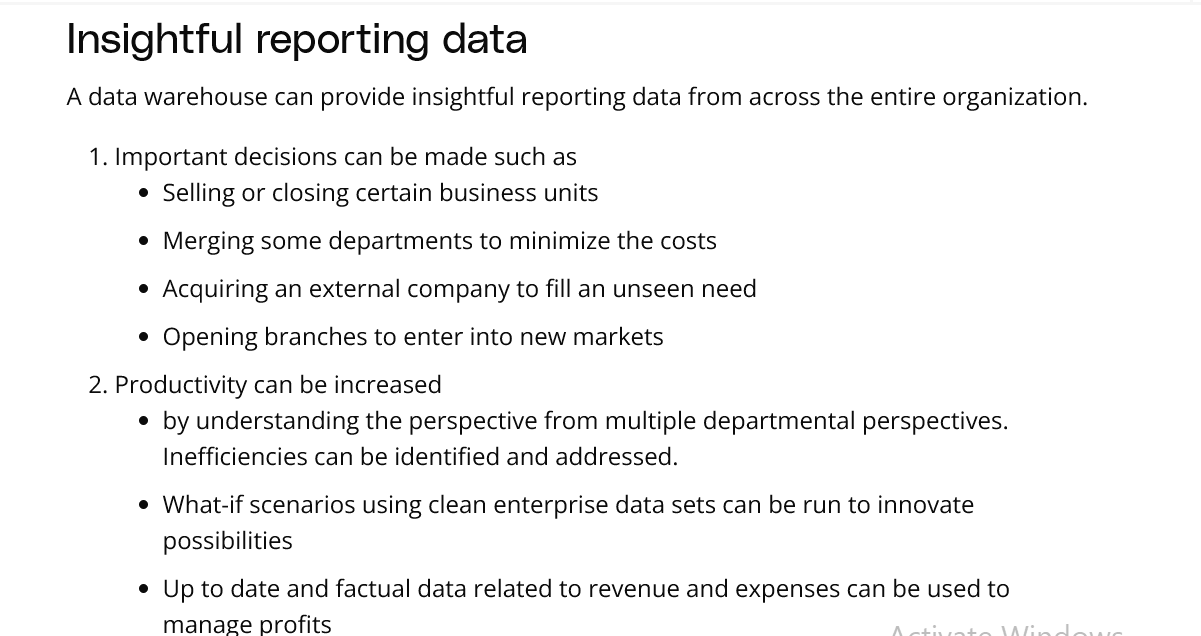

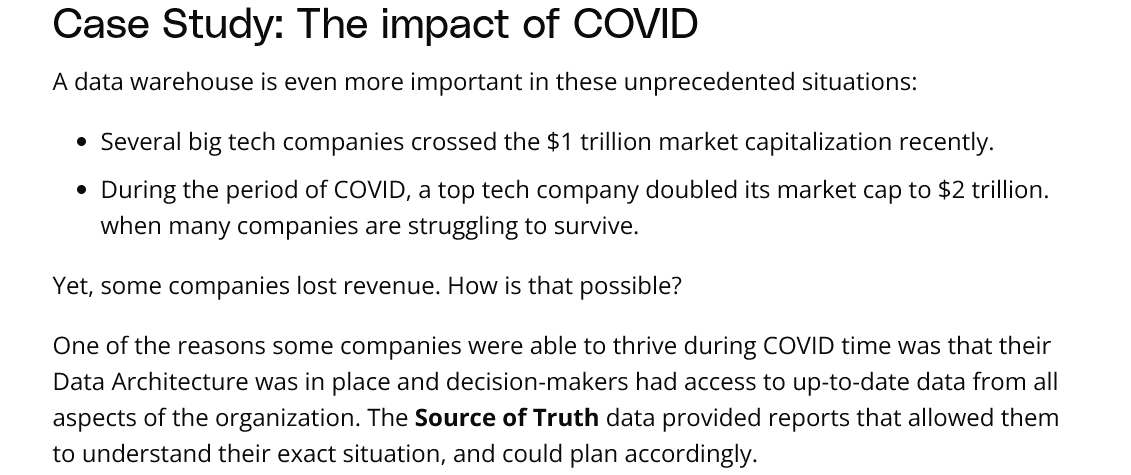

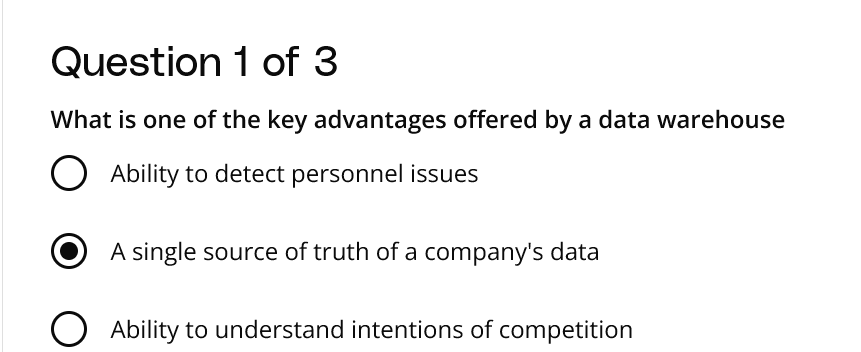

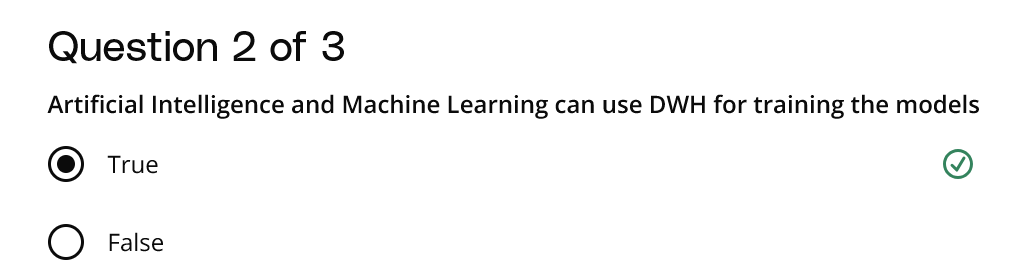

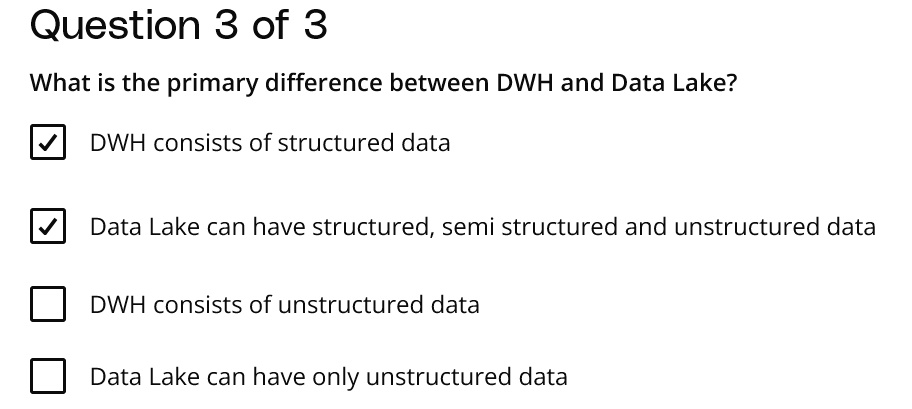

## ETL Data from ODS to DWH

https://www.youtube.com/watch?v=MPgPp8XEZIM

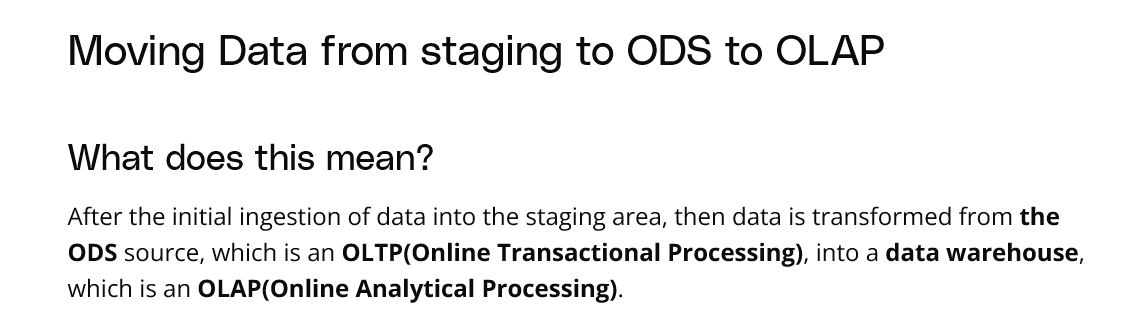

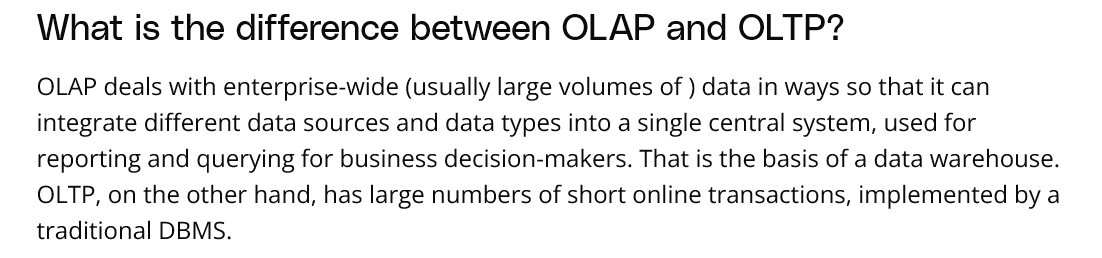

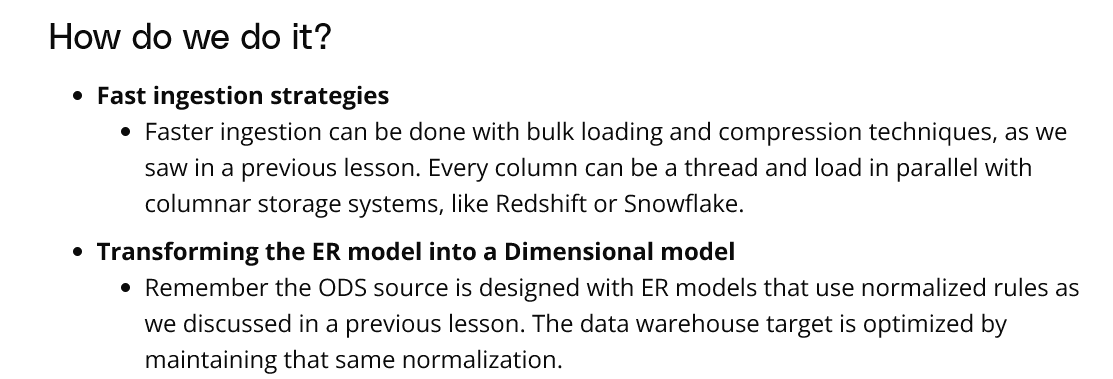

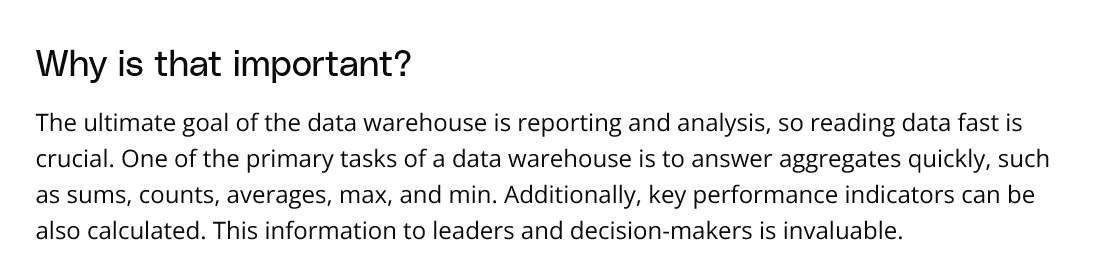

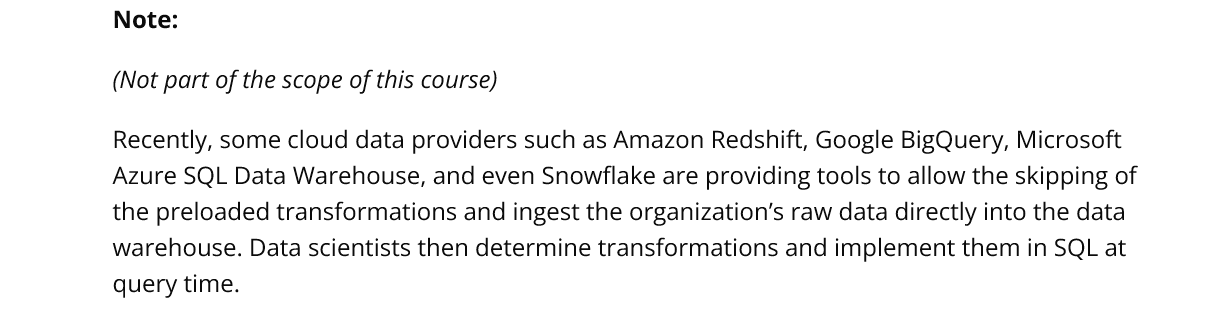

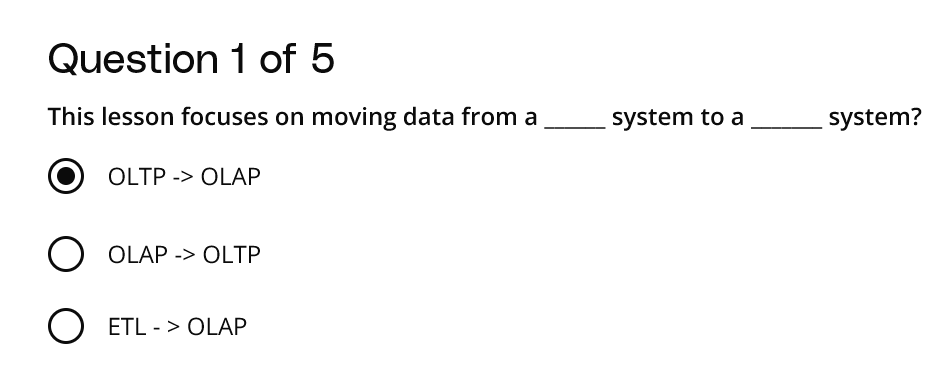

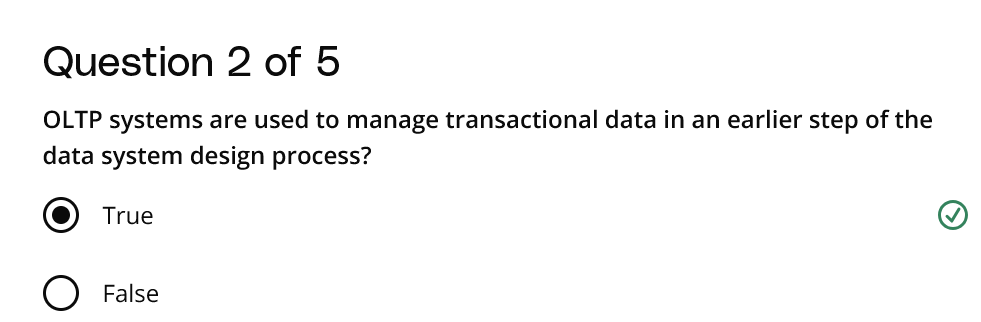

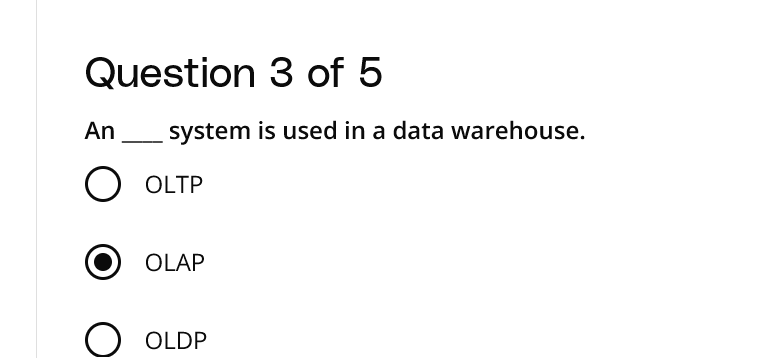

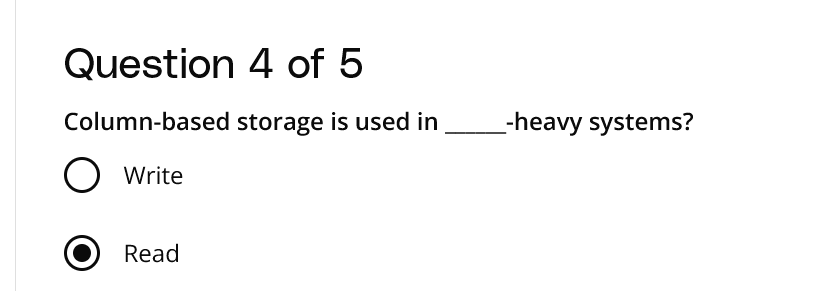

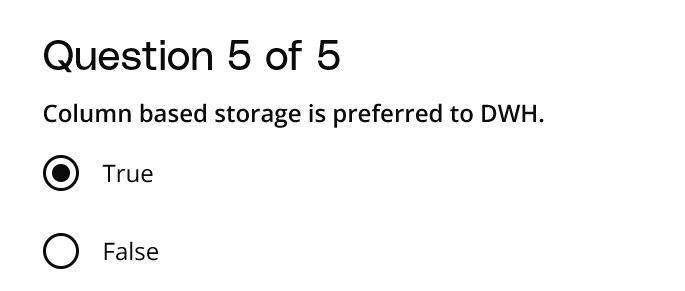

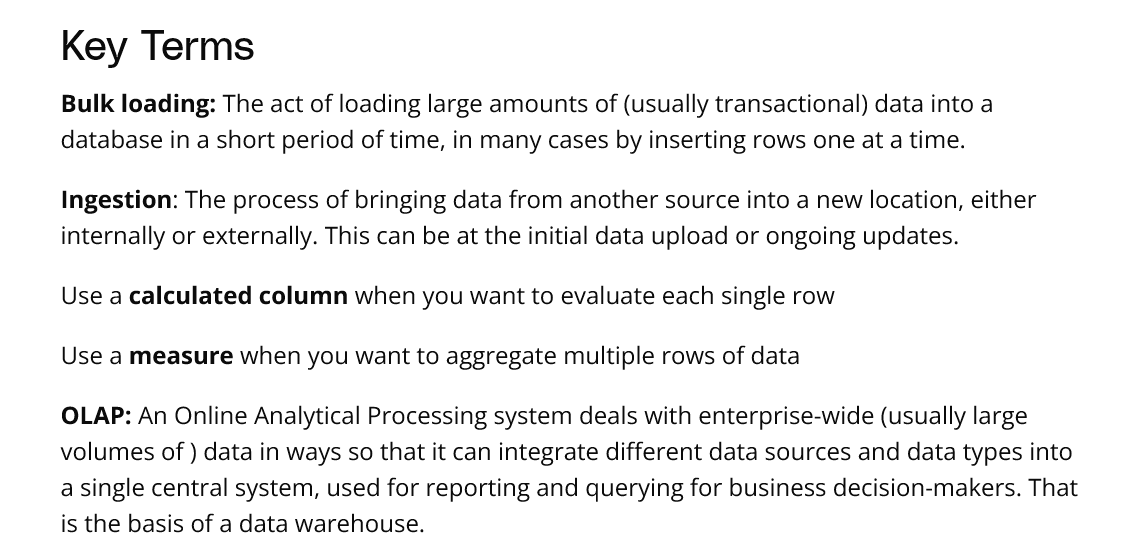

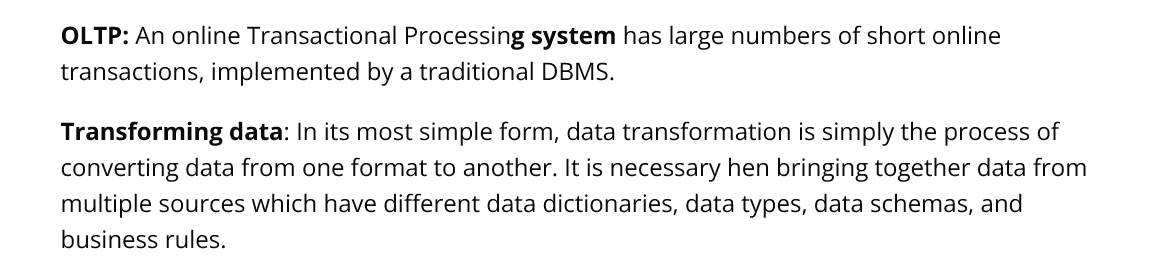

## Star vs Snowflake Schema

https://www.youtube.com/watch?v=YkAqQ9x9s8o

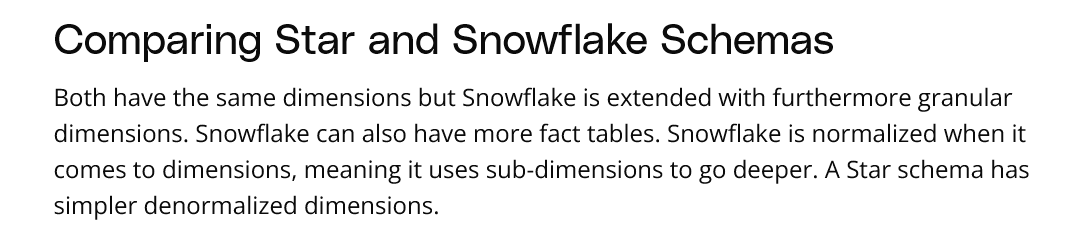

## Star Schema
As you can see below, the Star schema is a smaller schema, with less relationship information. Only the fact table is joined. These are typically used in Data Marts.

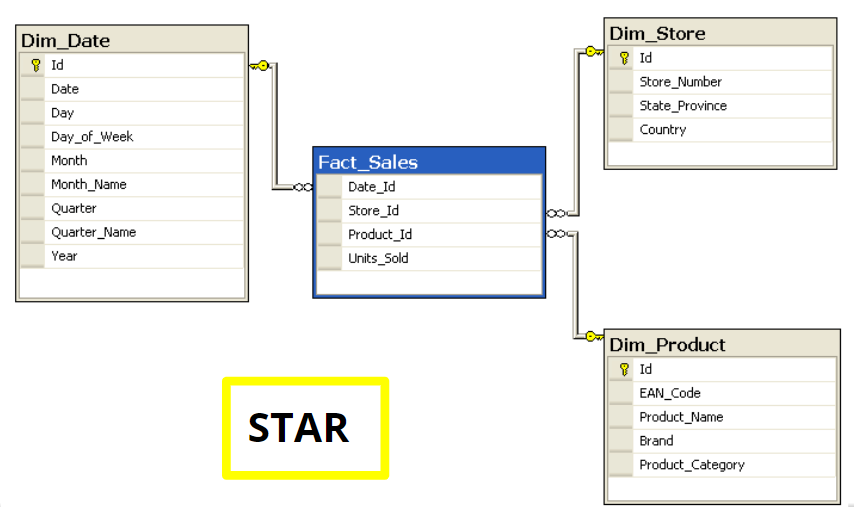

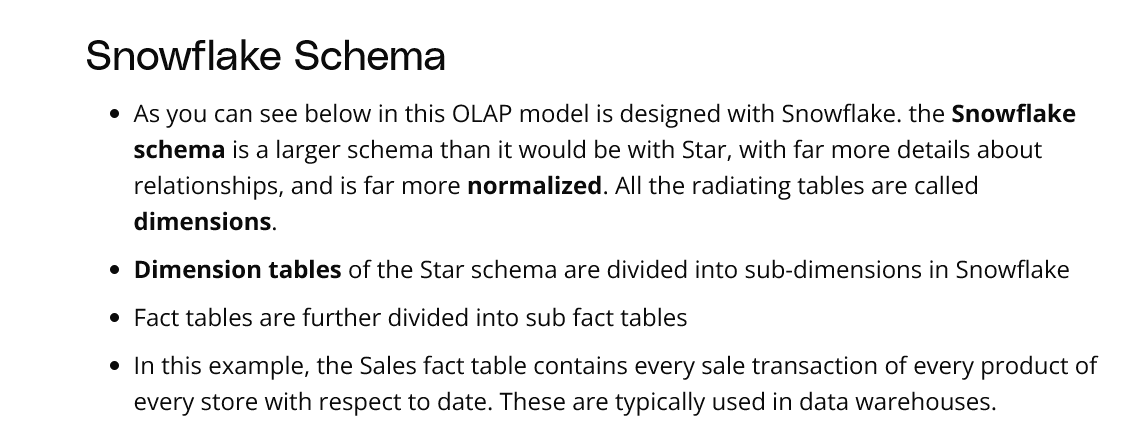

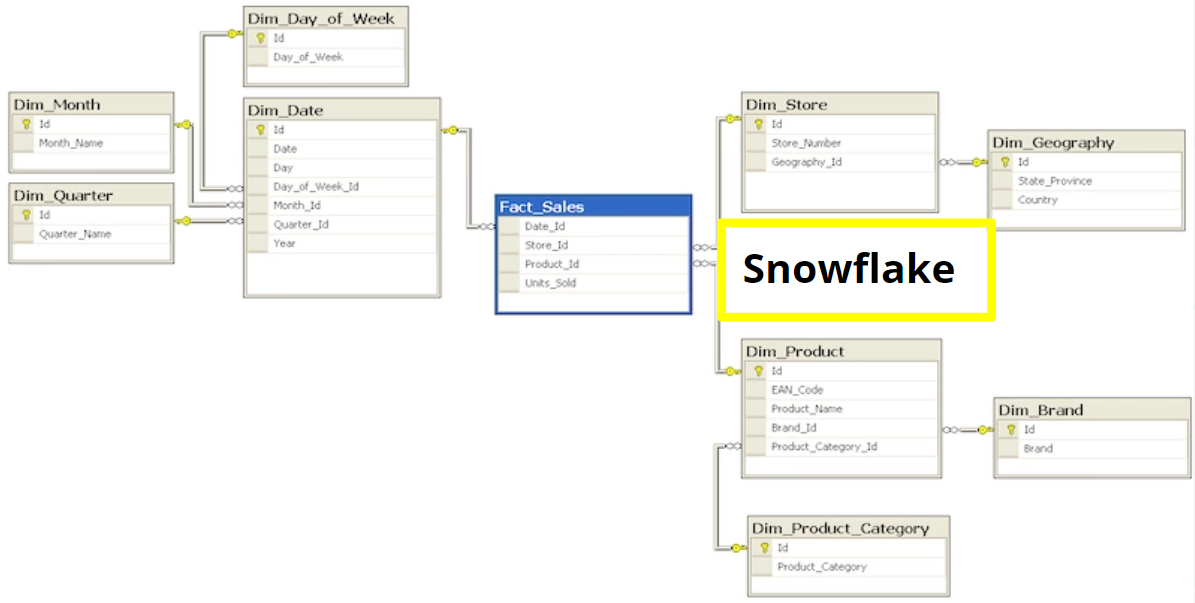png](attachment:8c63da4f-59a8-474b-b86e-9b0a5efd1d79.png)
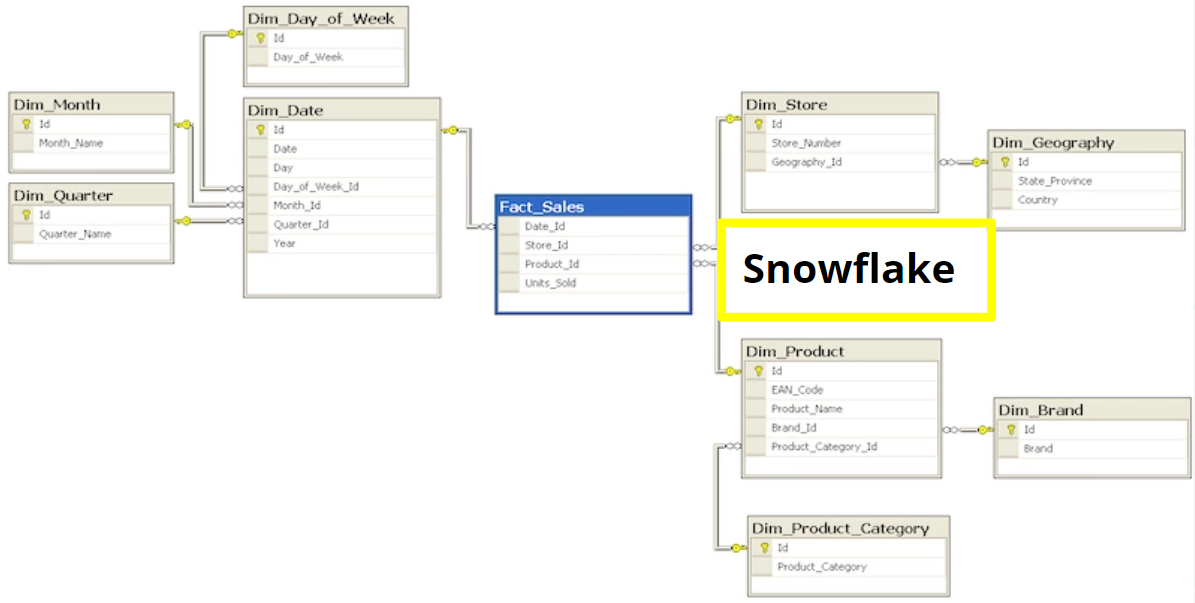

Snowflake Schema

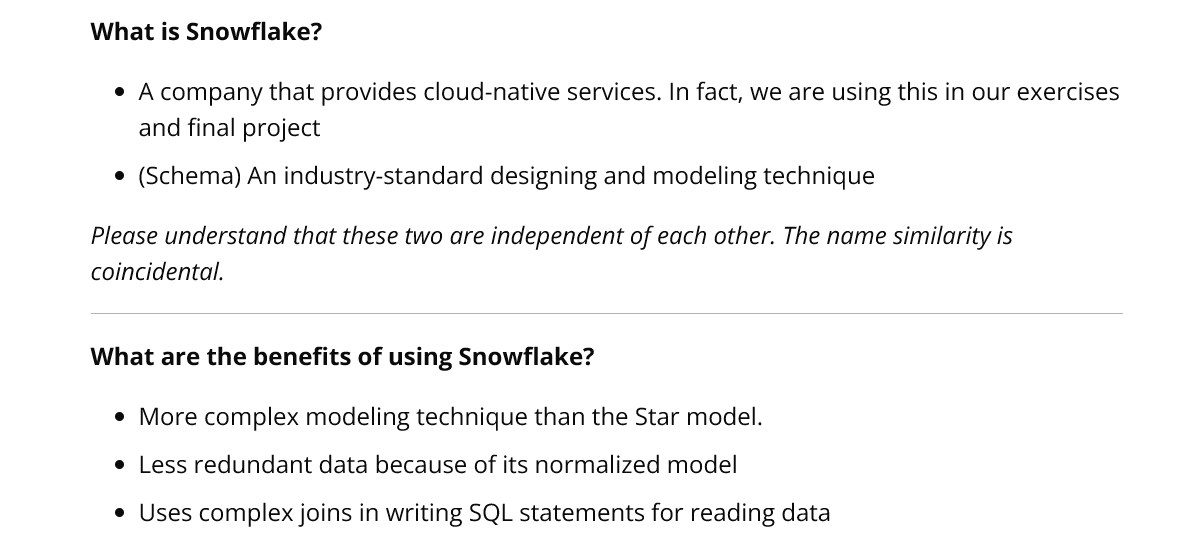

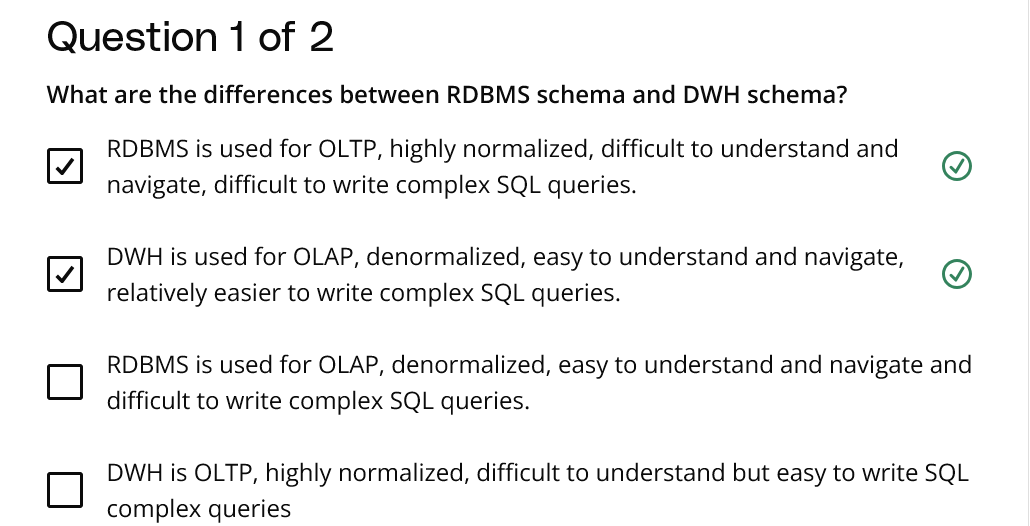

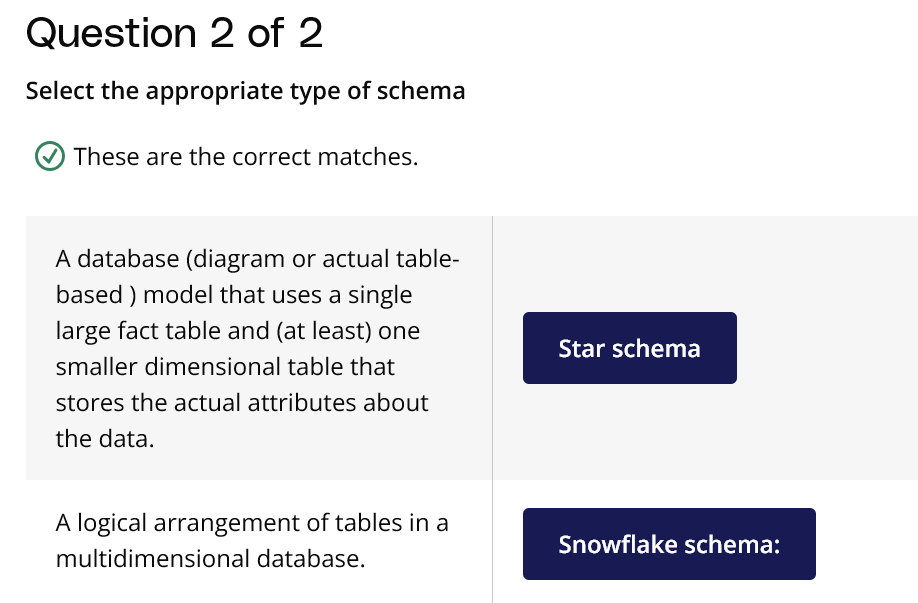

## Exercise: Compare Star vs Snowflake Schema

## Exercise: Compare Star vs Snowflake Schema

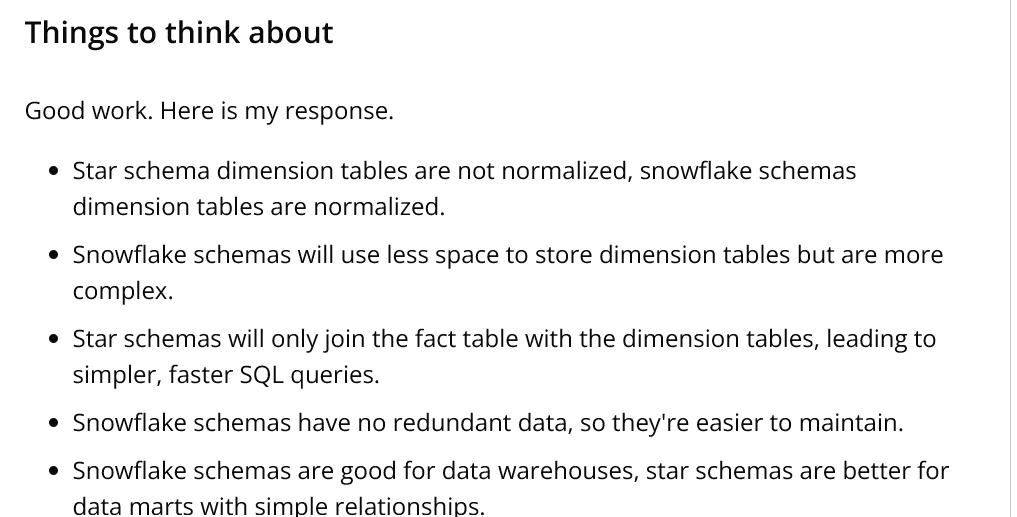

## Exercise: Selecting a Schema

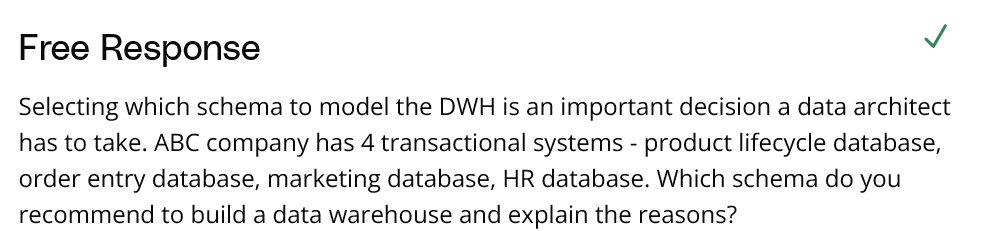

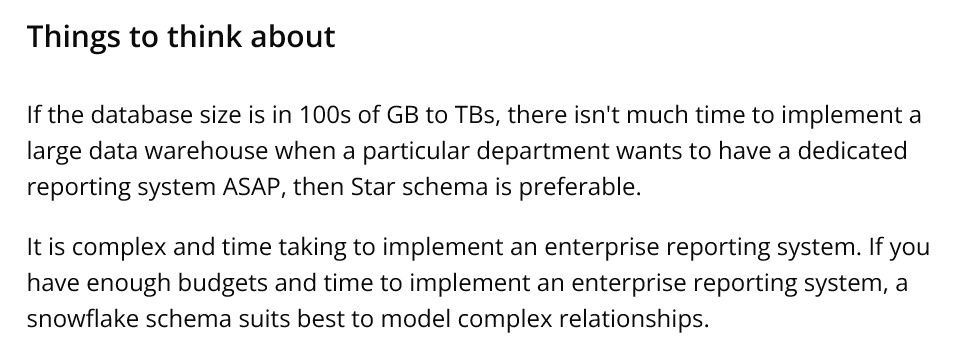

## Exercise Creating Dimensional Models

This is a continuation of the exercise you completed in the ODS lesson, where you created an ER model. That sample ER model is provided below as a supporting resource to help.

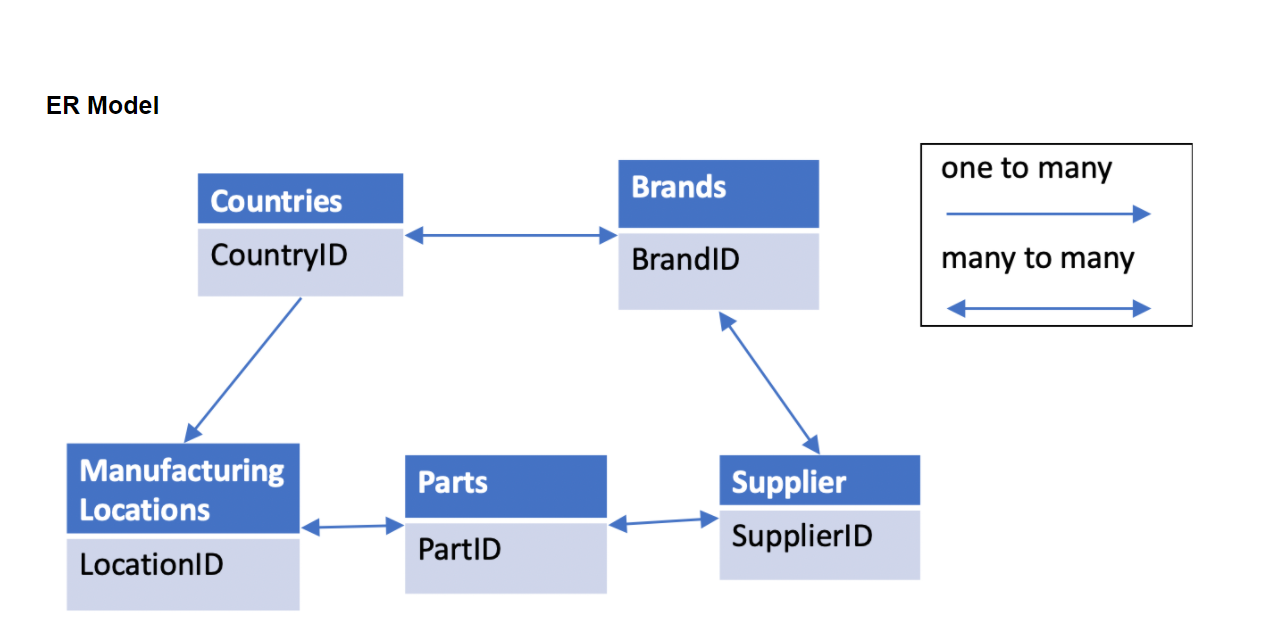

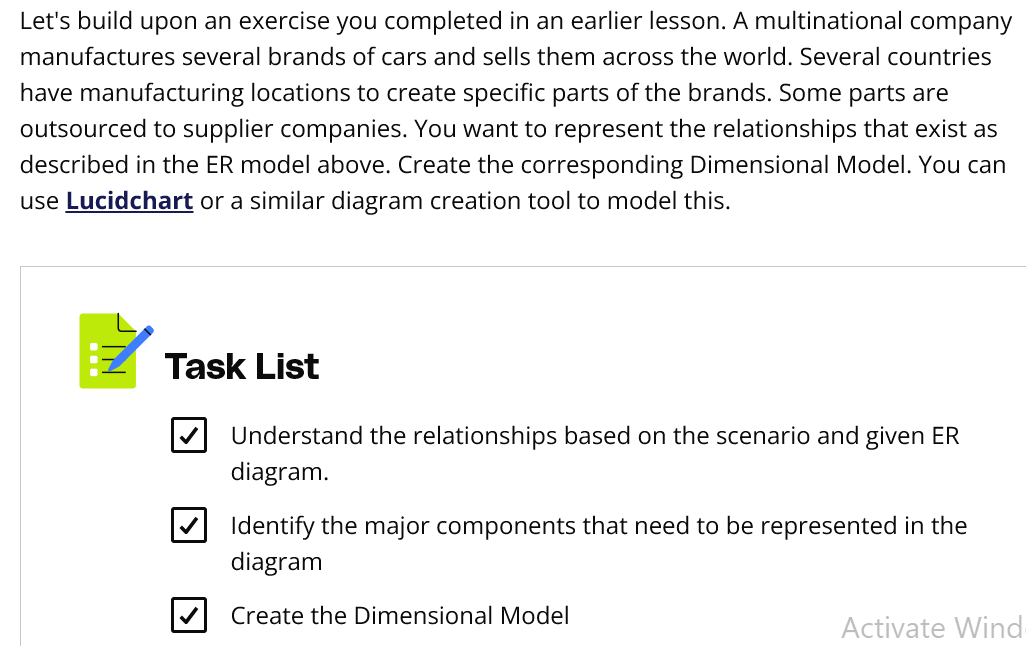

## Exercise Solution: Creating Dimensional Models

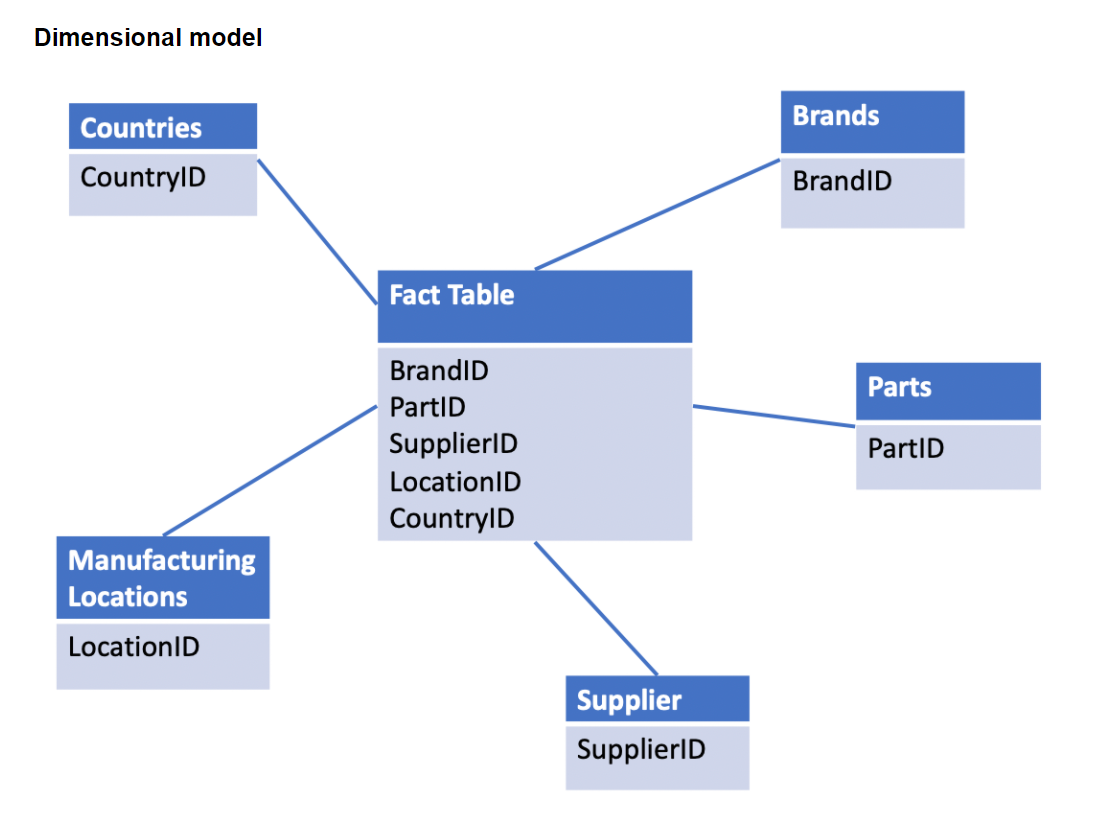

Depending on the ER model you used, your model may vary from this, which is acceptable as long as the relationships are still represented. This is also a higher-level model. You may have created a detailed model as we saw in earlier lessons. Both are effective tools depending on where you are at in the process of design. Notice the FACT table in the center of the diagram.

## Dimensions and Fact Tables

https://www.youtube.com/watch?v=wLoWAL35im0

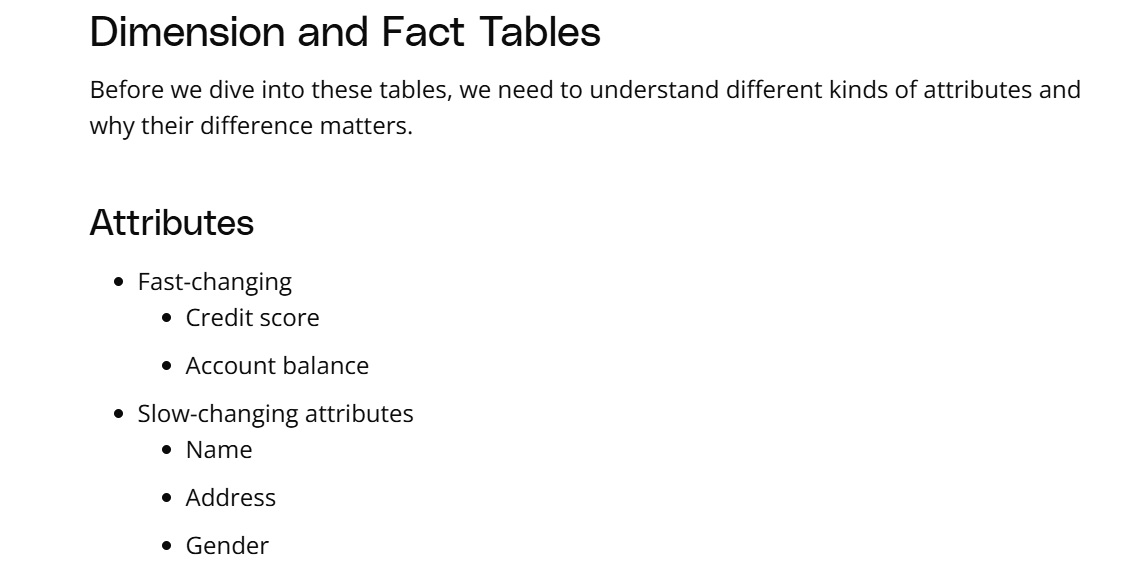

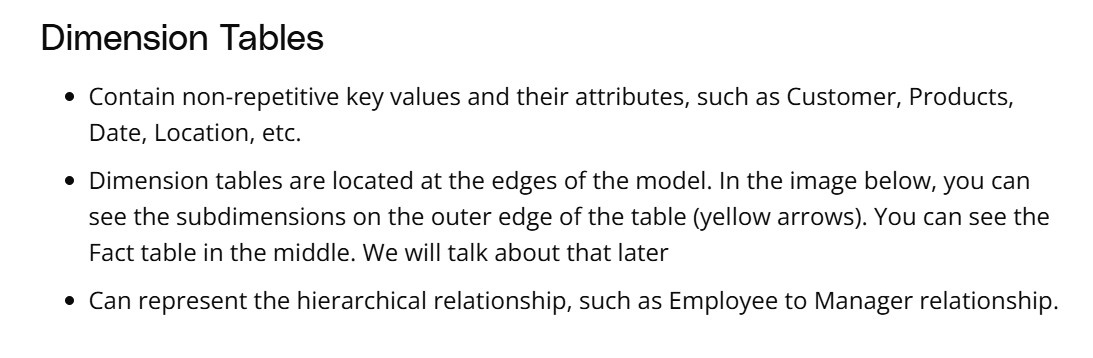

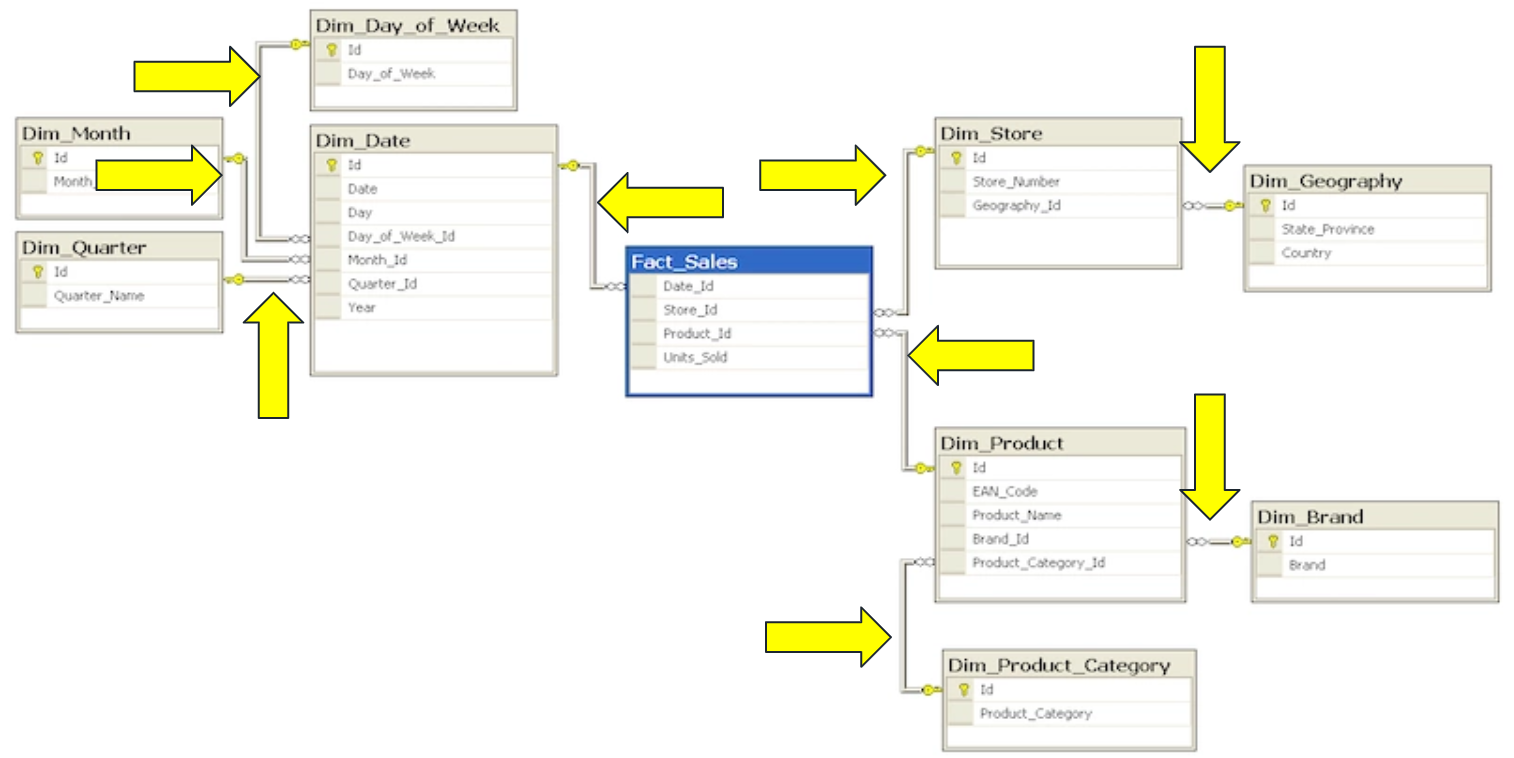

Dimensions on outer edges of table

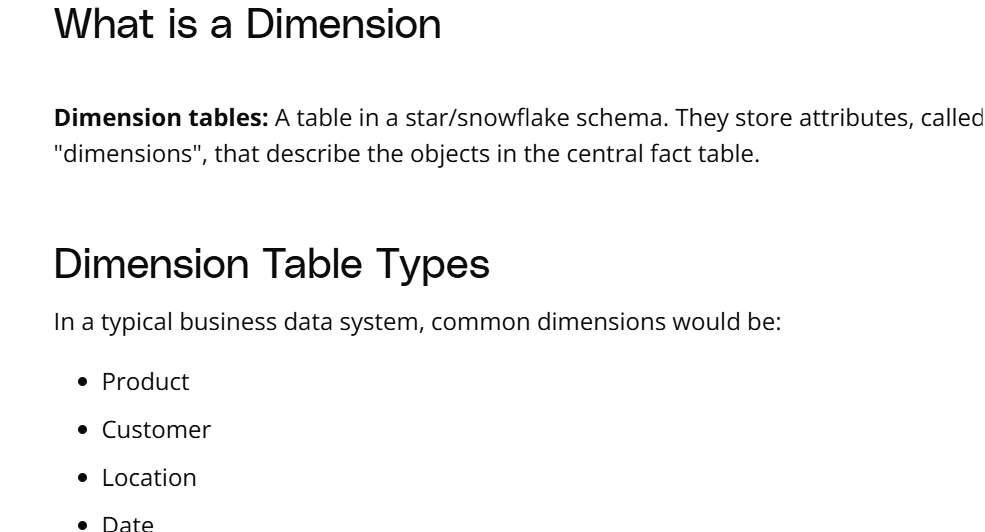

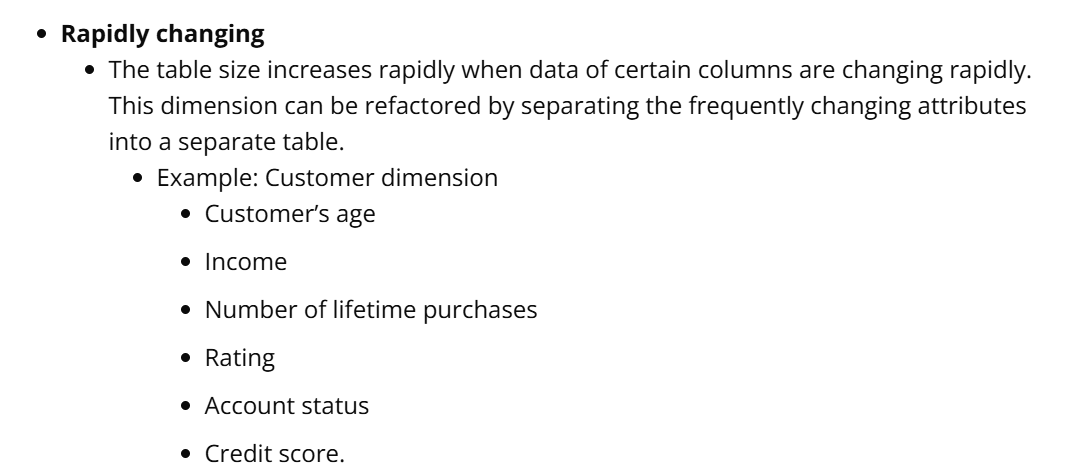

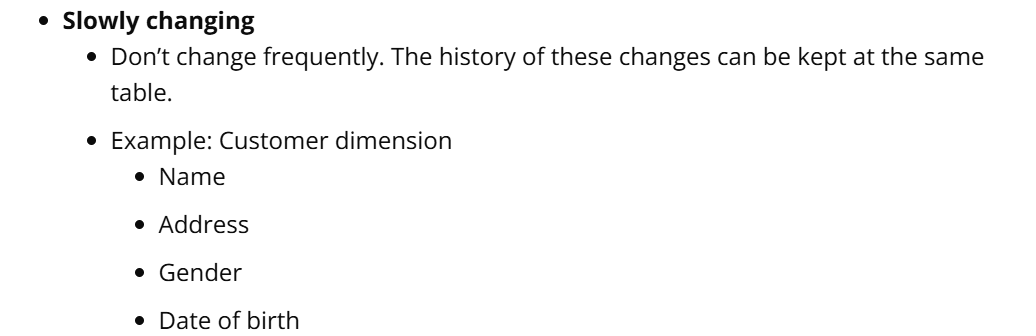

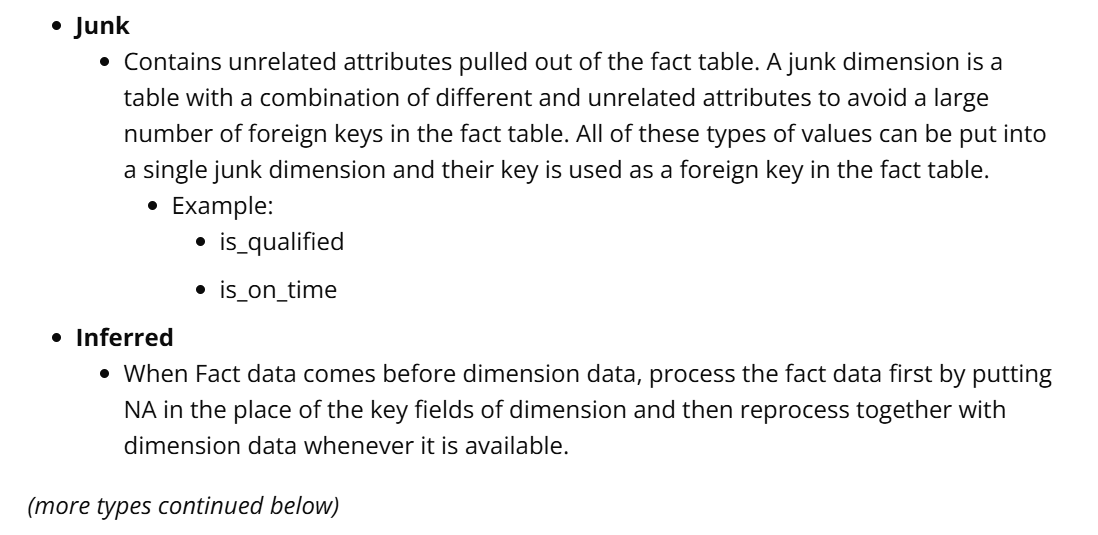

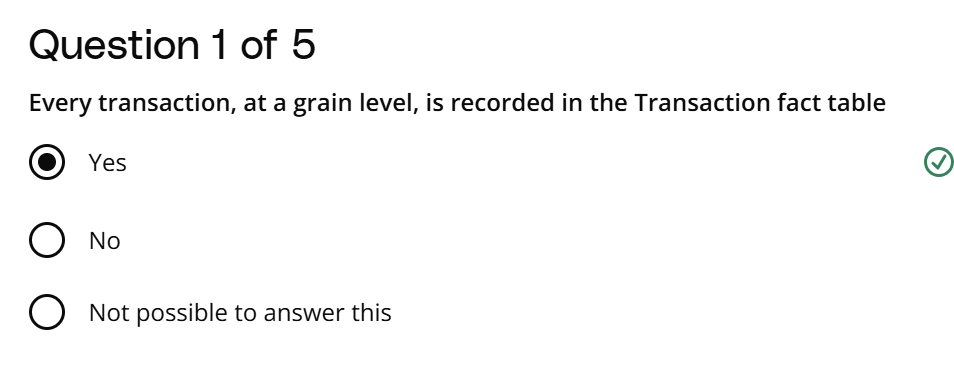

https://www.youtube.com/watch?v=YGGswHNqfbk

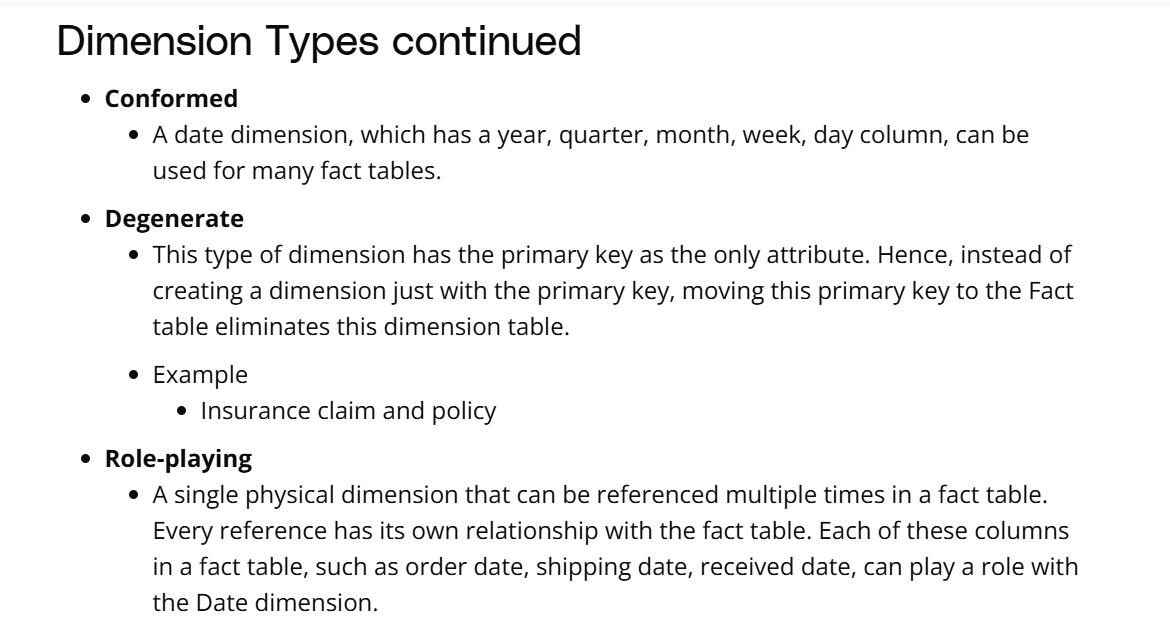

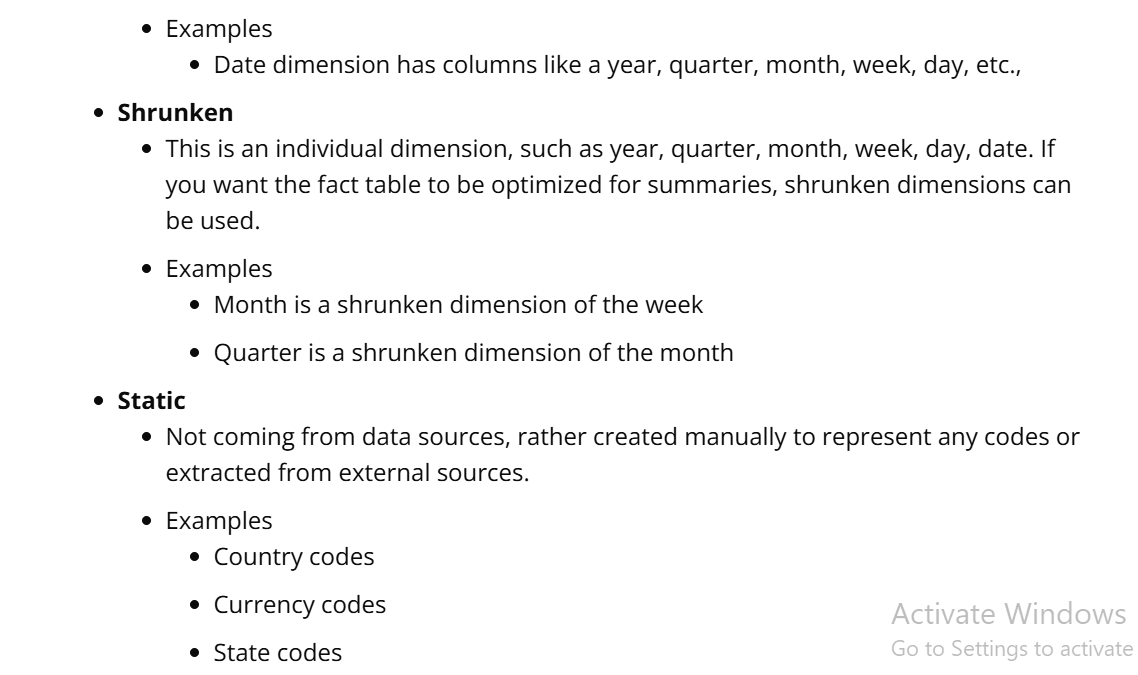

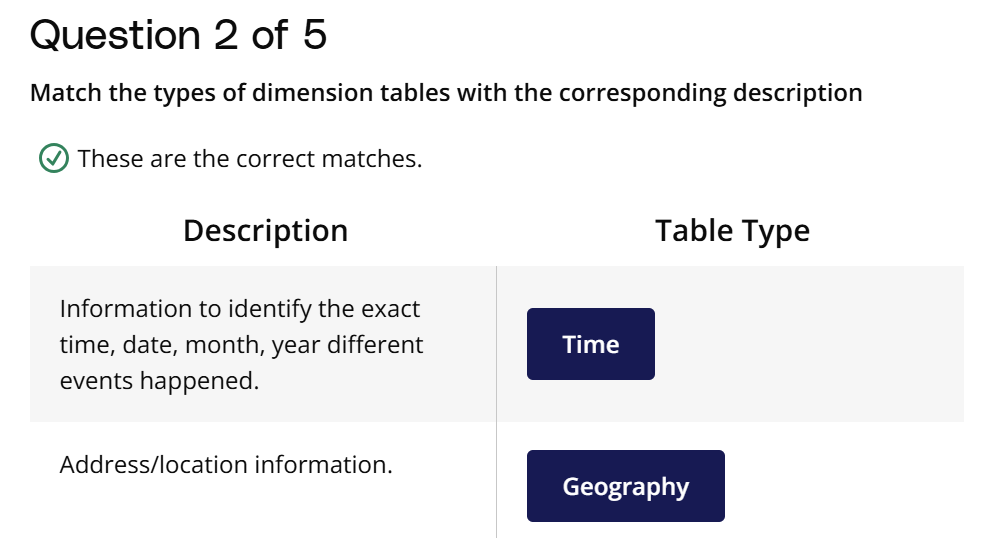

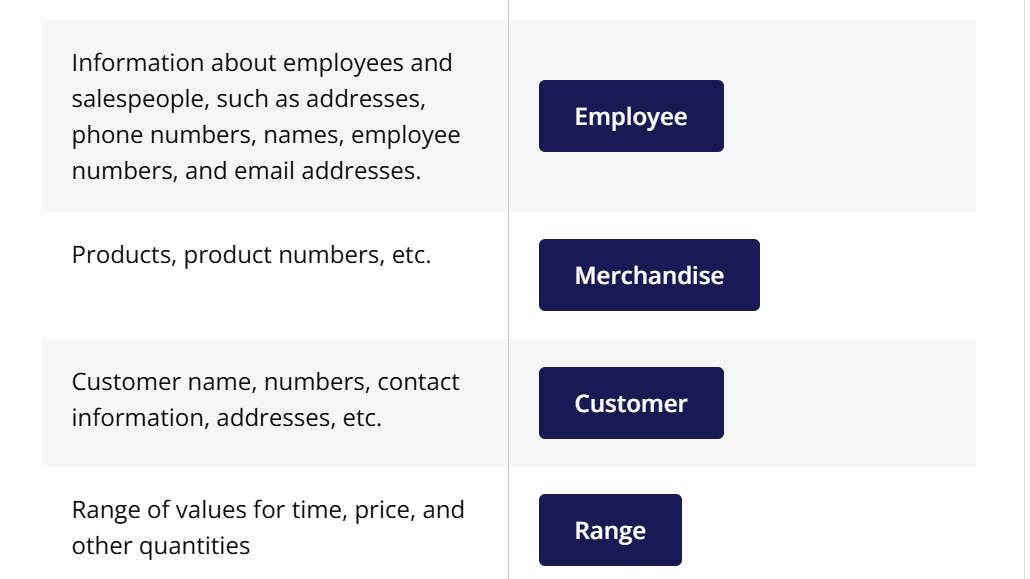

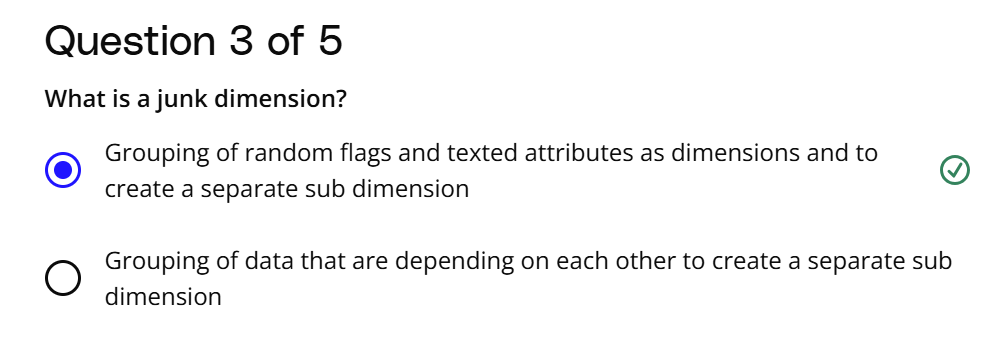

https://www.youtube.com/watch?v=UMNYMfYqNtg

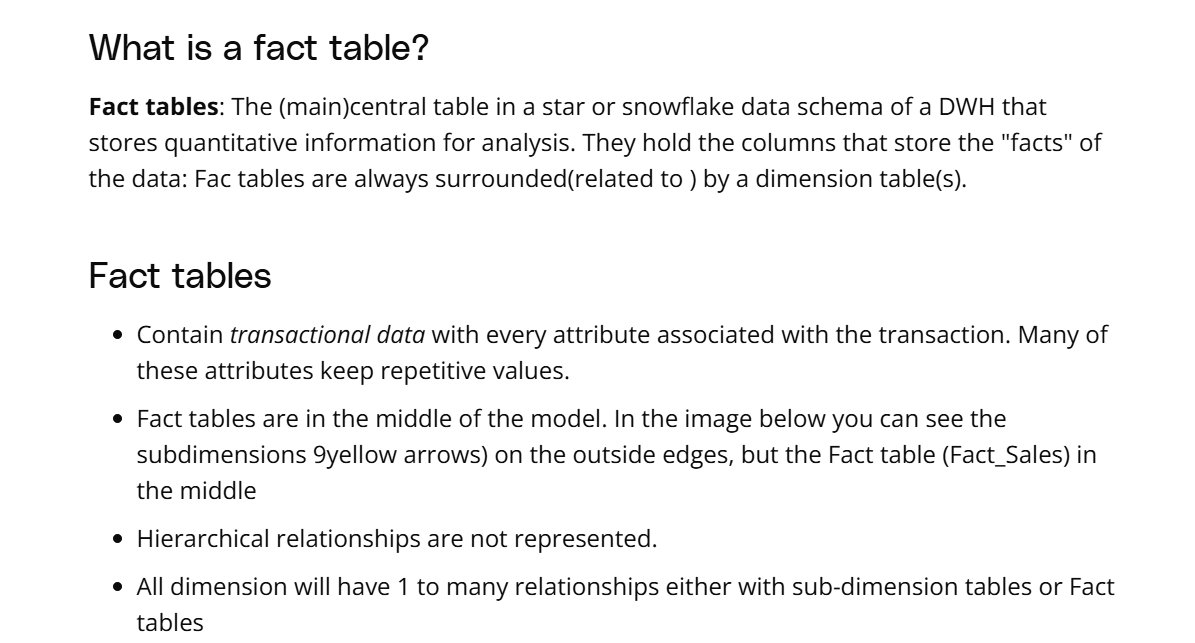

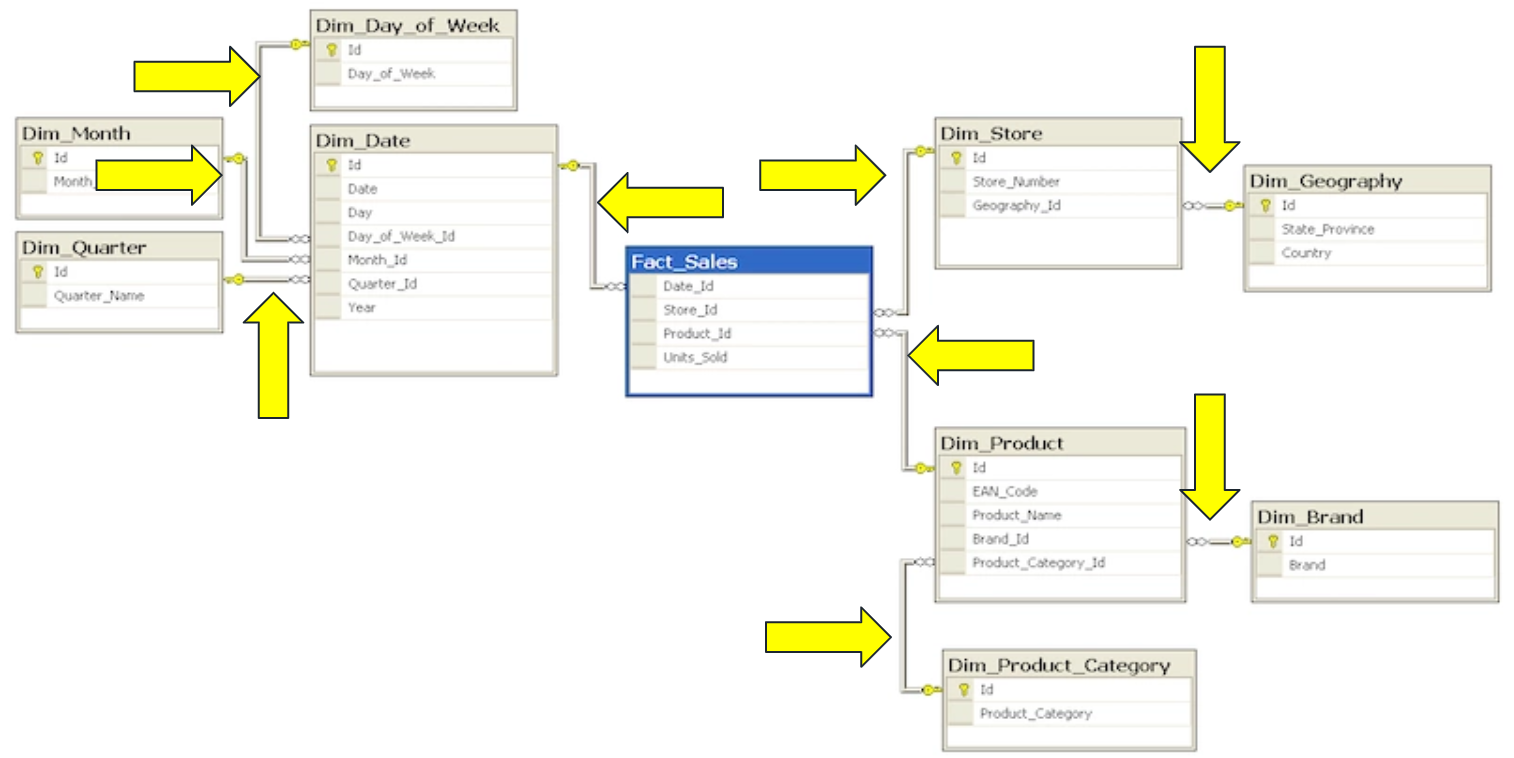

Fact table in the middle of the schema

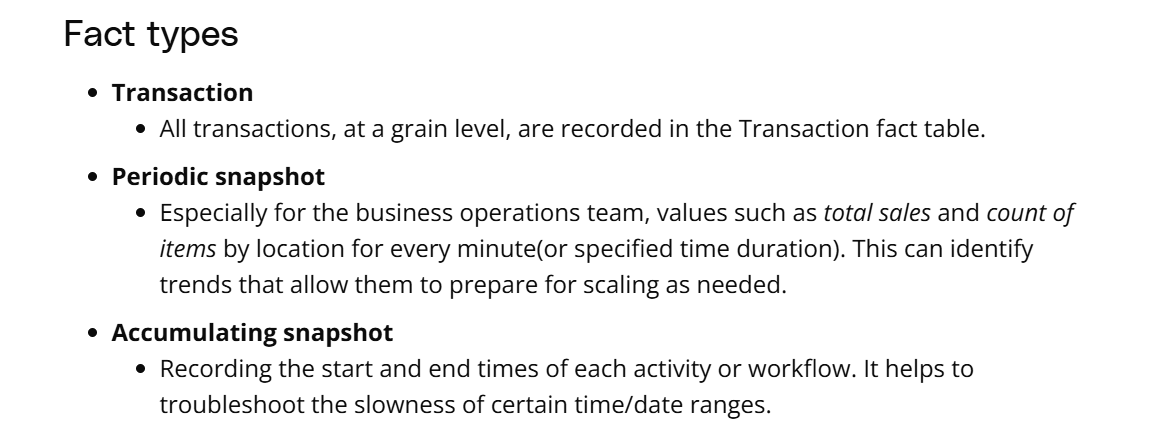

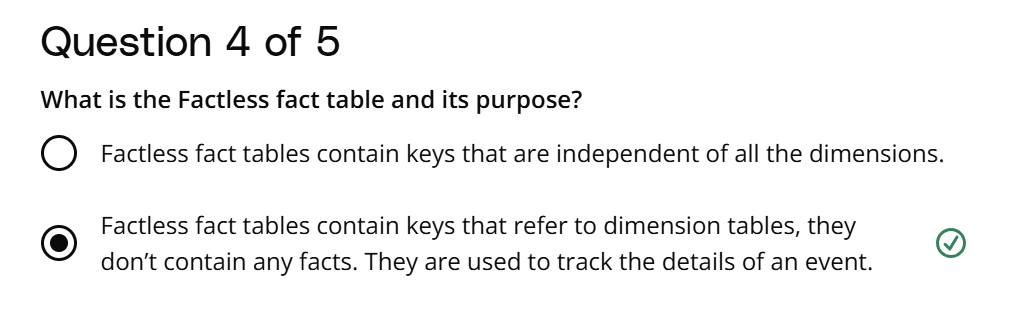

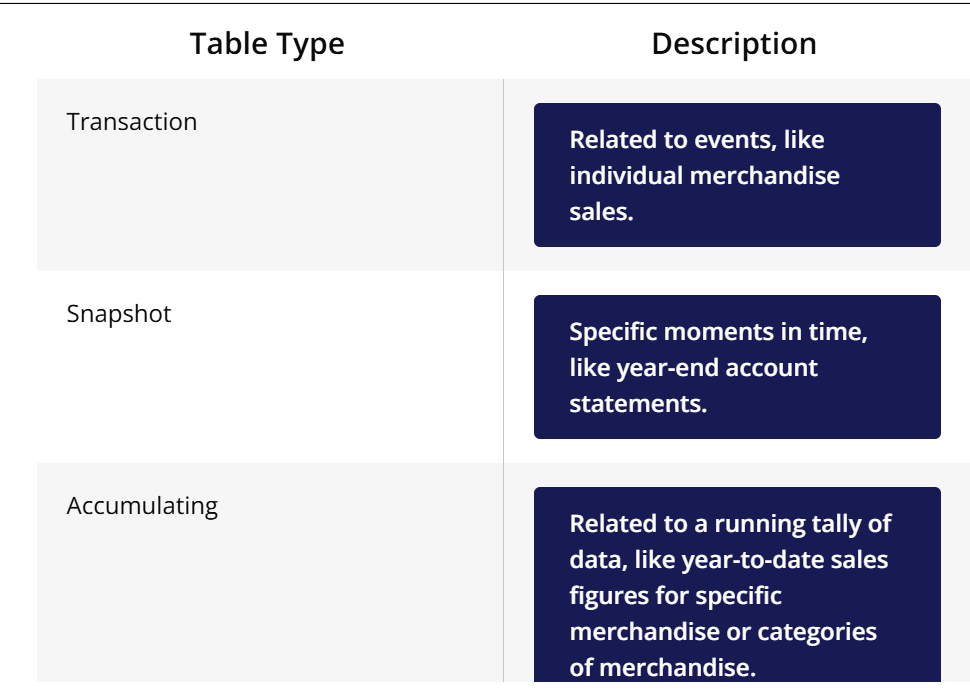

## Exercise: Data Warehouse from ODS using a Star Schema Model

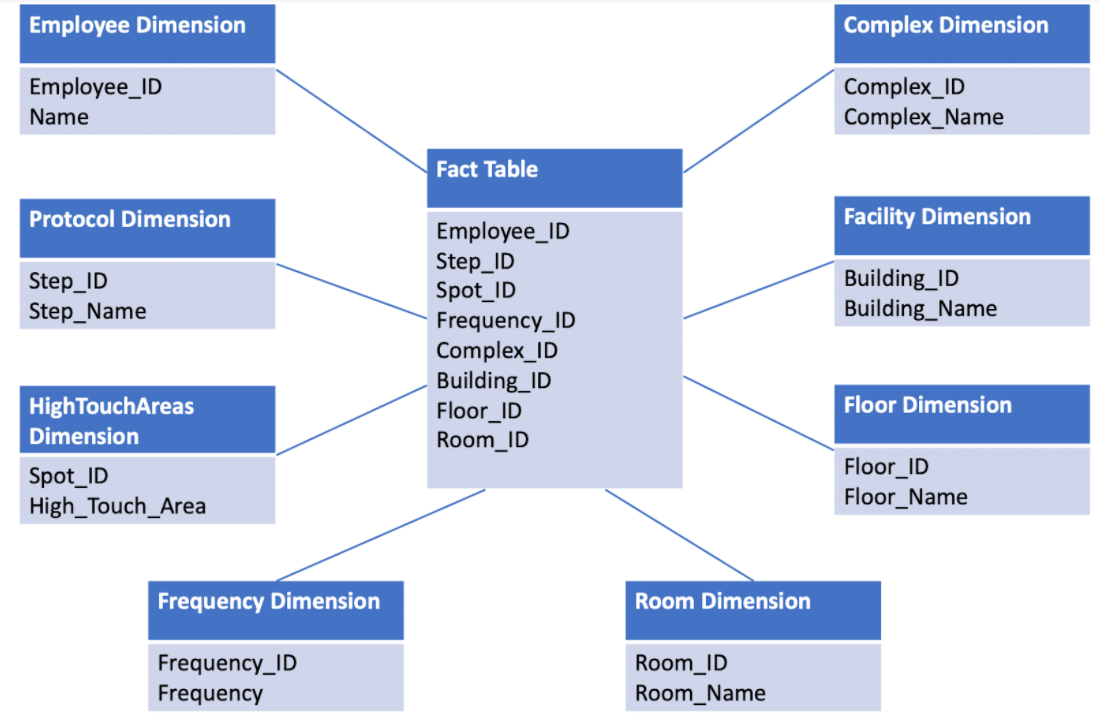

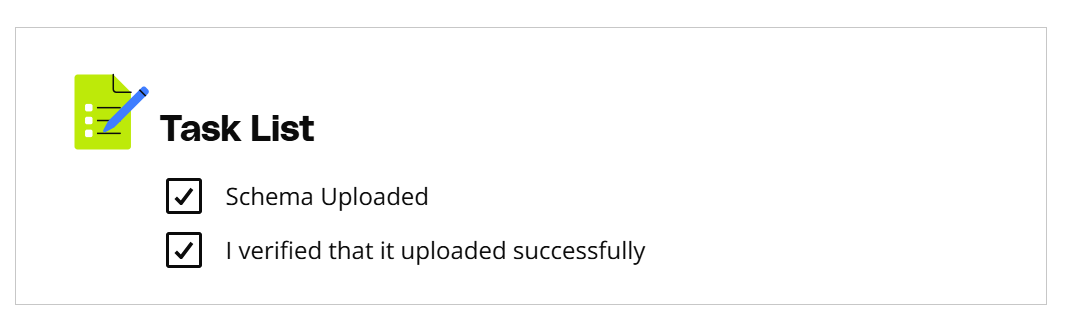

## Exercise Solution: DWH using Star Schema

Compare your SQL to what we have included here.



Step 1: Create Schema
CREATE SCHEMA DWH;

Step 2: DIMEMPLOYEE
create table DIMEMPLOYEE ( EMPLOYEE_ID NUMBER, FIRST_NAME STRING, LAST_NAME STRING );

insert into DIMEMPLOYEE select distinct EMPLOYEE_ID, FIRST_NAME, LAST_NAME from ods.EMPLOYEE;

Step 3: Create Table DIMPROTOCOL
create table DIMPROTOCOL( STEP_ID NUMBER, STEP_NAME string );

insert into DIMPROTOCOL select distinct STEP_ID, STEP_NAME from ods.PROTOCOL;

Step 4 : Create Table DIMHIGHTOUCHAREAS
create table DIMHIGHTOUCHAREAS( SPOT_ID NUMBER, HIGH_TOUCH_AREA string );

insert into DIMHIGHTOUCHAREAS select distinct SPOT_ID, HIGH_TOUCH_AREA from ods.HIGHTOUCHAREAS;

Step 5 : Create Table DIMFREQUENCY
create table DIMFREQUENCY( FREQUENCY_ID NUMBER, FREQUENCY NUMBER );

insert into DIMFREQUENCY select distinct FREQUENCY_ID, FREQUENCY from ods.FREQUENCY;

Step 6: Create Table DIMROOM
create table DIMROOOM( ROOM_ID NUMBER, ROOM_NAME STRING );

insert into DIMROOOM select distinct ROOM_ID, ROOM_NAME from ods.ROOMS;

Step 7 : Create Table DIMFLOORS
create table DIMFLOORS( FLOOR_ID number, FLOOR_NAME STRING );

insert into DIMFLOORS select distinct FLOOR_ID, FLOOR_NAME from ods.FLOORS;

Step 8 : Create Table DIMFACILITY
create table DIMFACILITY ( BUILDING_ID NUMBER, BUILDING_NAME STRING );

insert into DIMFACILITY select distinct BUILDING_ID, BUILDING_NAME from ods.FACILITY;

Step 9 : Create Table DIMCOMPLEX
create table DIMCOMPLEX ( COMPLEX_ID STRING, COMPLEX_NAME STRING );

insert into DIMCOMPLEX select distinct COMPLEX_ID, COMPLEX_NAME from ods.COMPLEX;

Step 10 : Create Table FACTTABLE
create table facttable_CleaningSchedule (   
EMPLOYEE_ID NUMBER,   
FIRST_NAME STRING,   
LAST_NAME STRING,   
STEP_ID NUMBER,   
STEP_NAME string,   
SPOT_ID NUMBER,   
HIGH_TOUCH_AREA string,   
FREQUENCY_ID NUMBER,   
FREQUENCY NUMBER,   
ROOM_ID NUMBER,   
ROOM_NAME STRING,

constraint fk_EMPLOYEE_id foreign key (EMPLOYEE_id)
references DIMEMPLOYEE (EMPLOYEE_ID),   
constraint fk_SPOT_id foreign key (SPOT_id)
references DIMHIGHTOUCHAREAS (SPOT_id),   
constraint fk_FREQUENCY_id foreign key (FREQUENCY_id)
references DIMFREQUENCY(FREQUENCY_id),   
constraint fk_ROOM_id foreign key (ROOM_id)
references DIMROOOM (ROOM_id)
);

Step 11 Inserting the appropriate data into facttable_CleaningSchedule
INSERT INTO facttable_cleaningschedule
SELECT DISTINCT E.employee_id,
                E.first_name,
                E.last_name,
                P.step_id,
                P.step_name,
                HTA.spot_id,
                HTA.high_touch_area,
                FQ.frequency_id,
                FQ.frequency,
                R.room_id,
                R.room_name
FROM   dimemployee E,
       dimfacility F,
       dimfloors FL,
       dimfrequency FQ,
       dimhightouchareas HTA,
       dimprotocol P,
       dimrooom R,
       ods.cleaningschedule S
WHERE  ( E.employee_id = S.employeeid )
       AND ( P.step_id = S.stepid )
       AND ( HTA.spot_id = S.spotid )
       AND ( FQ.frequency_id = S.frequencyid )
       AND ( R.room_id = S.roomid ); 
Done!



## Reporting

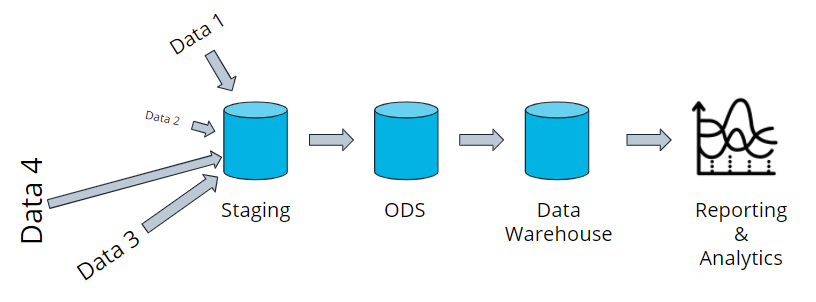

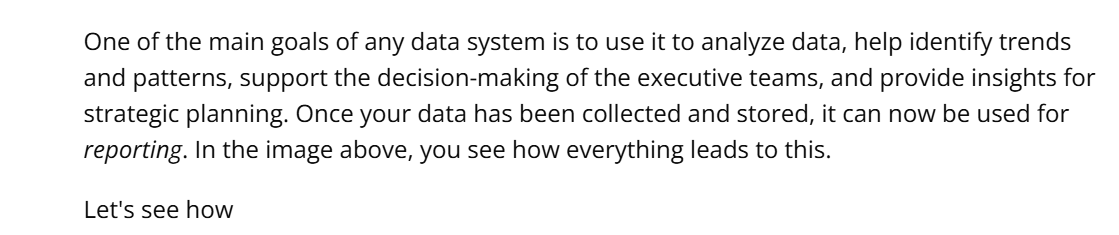

https://www.youtube.com/watch?v=Ln6Tsj9oyxA

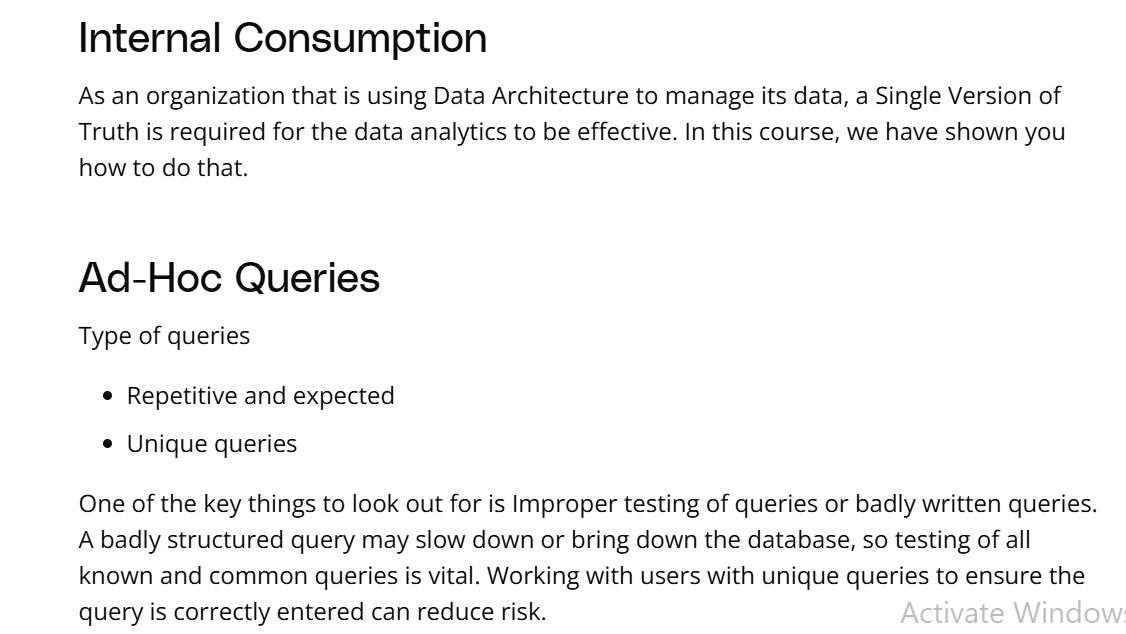

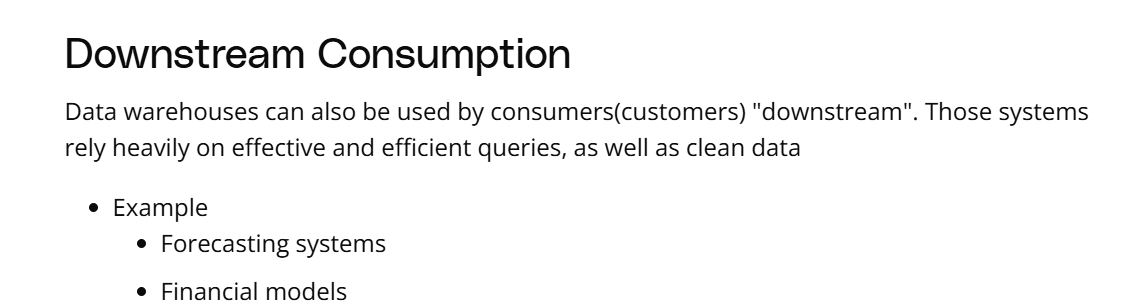

Case study: There are over 200 stock exchanges in the world sending the stock market tick data at a rate of over a million messages per second. Companies, like Reuters and Bloomberg, buy this data, clean and aggregate it into streams to sell to customers. Customers subscribe to these feeds to buy and sell the stocks. When the entire database of all departments of the organization is available, it is possible to find some new opportunities for revenue generation.

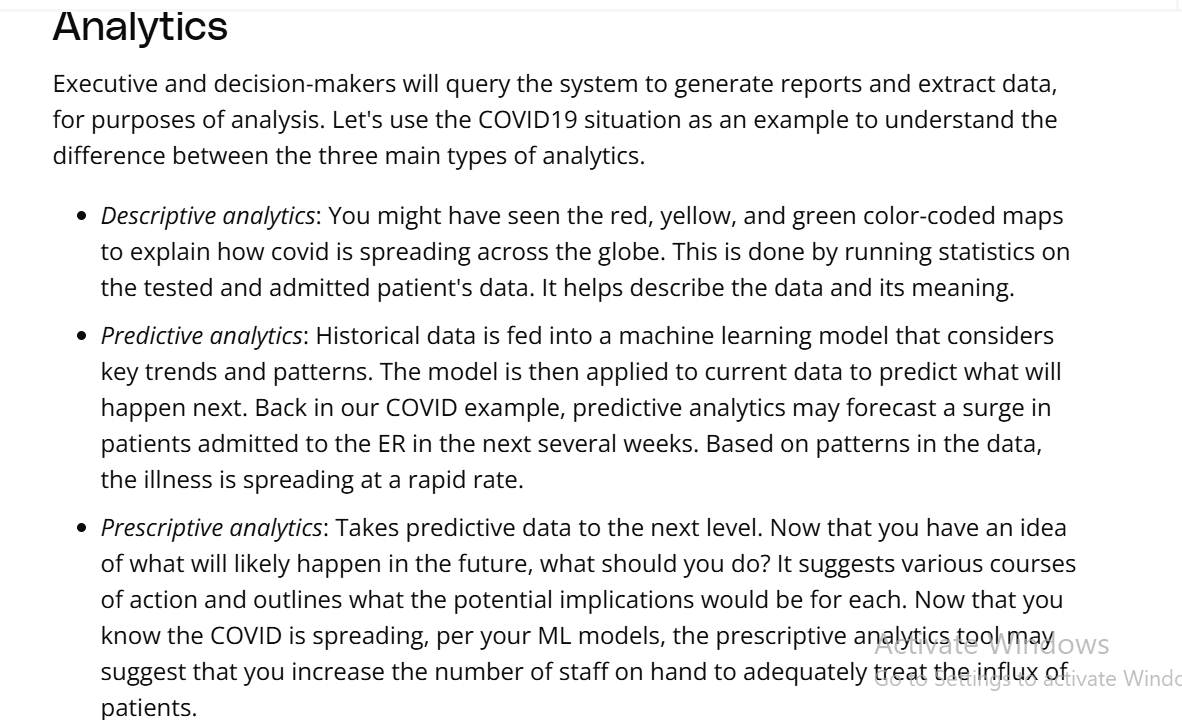

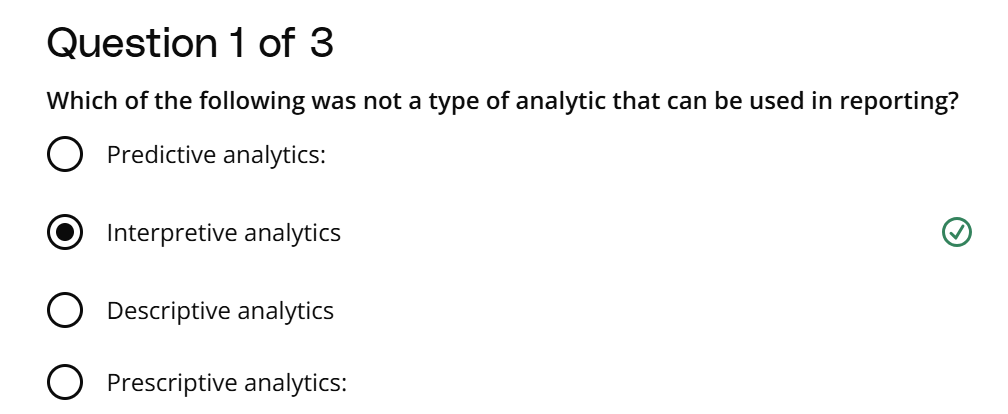

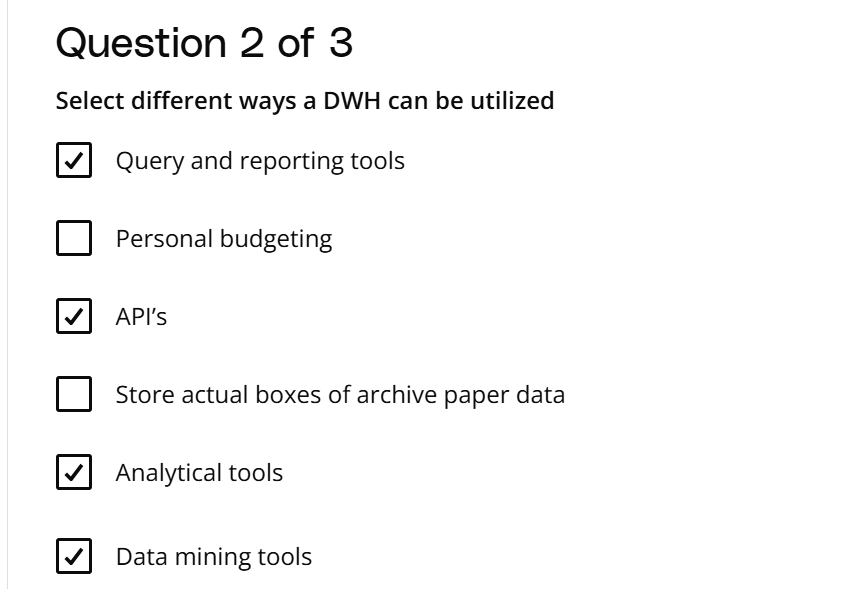

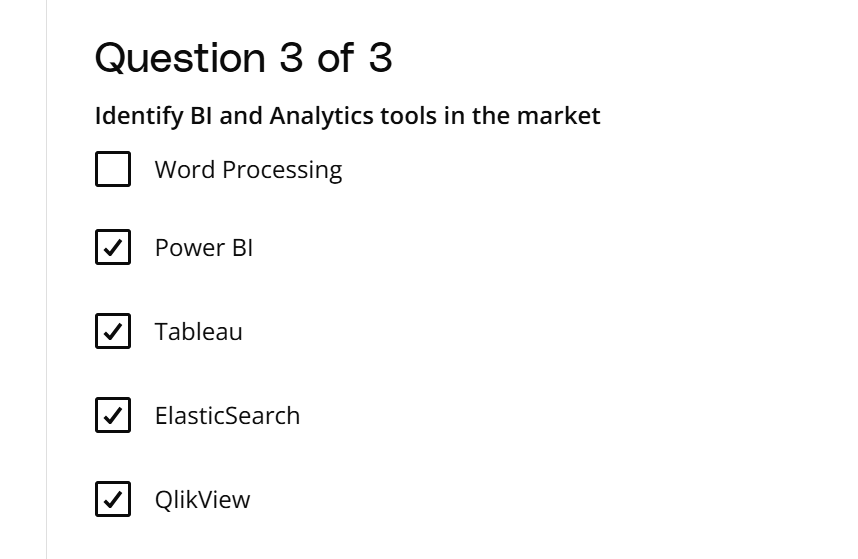

## Exercise: Writing SQL that Correlates Business Intelligence

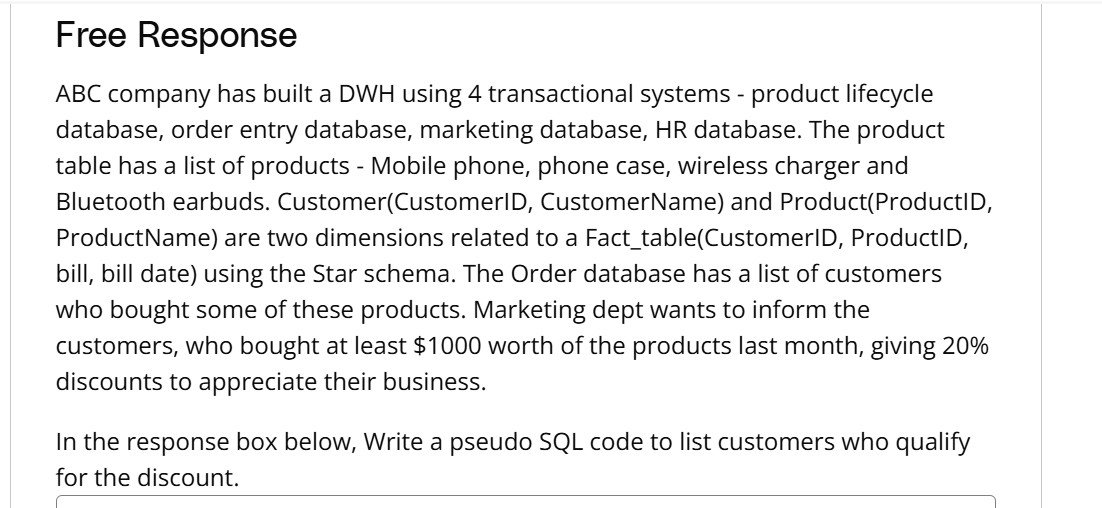

select c.customerName, sum(f.bill) from Customers c, Fact_table f where c.customerID = f.customerID and ((f.billdate between currentDate and (currentDate -30)))  group by c.customerID having sum(f.bill) >= 1000;

Exercise: Business Value of Enterprise Datasets

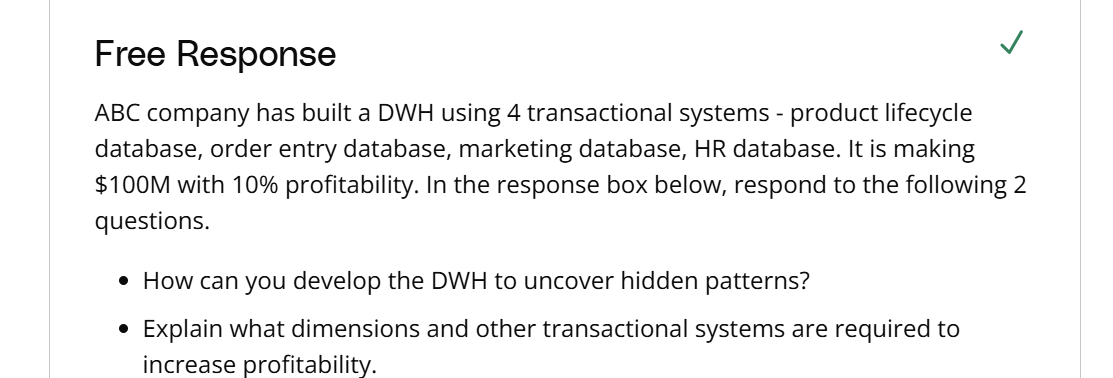

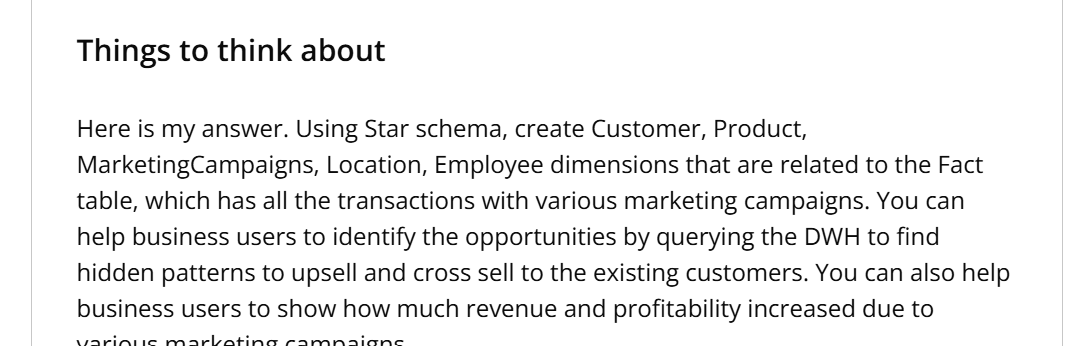

## Edge Cases

https://www.youtube.com/watch?v=1N8avloX1OA

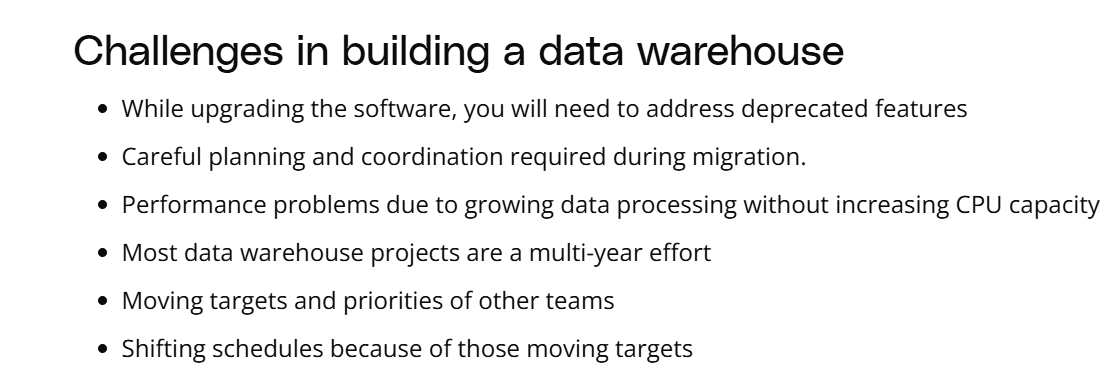

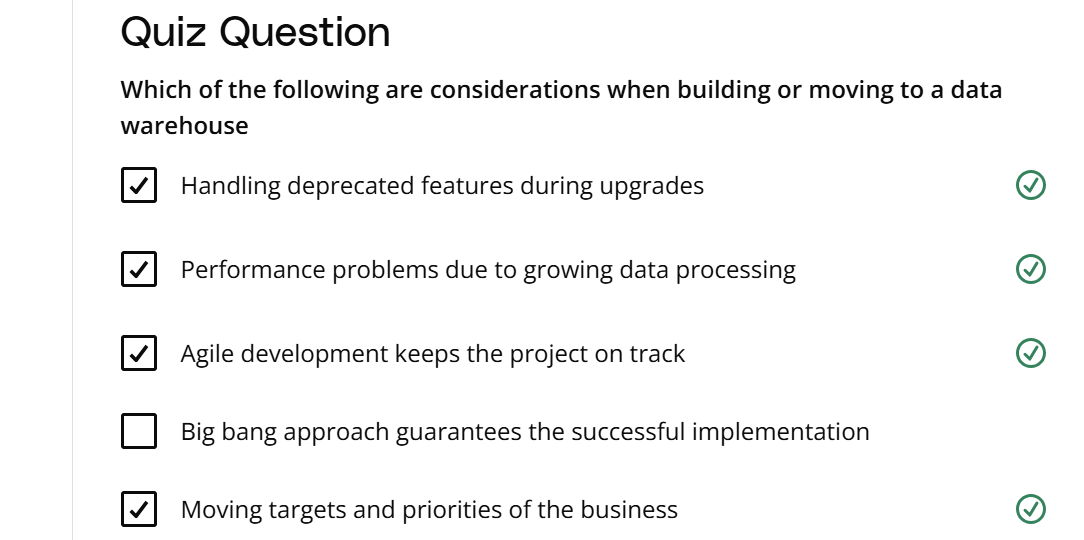

## How Experts See Data Warehousing

https://www.youtube.com/watch?v=8d0jGjY3Dz0

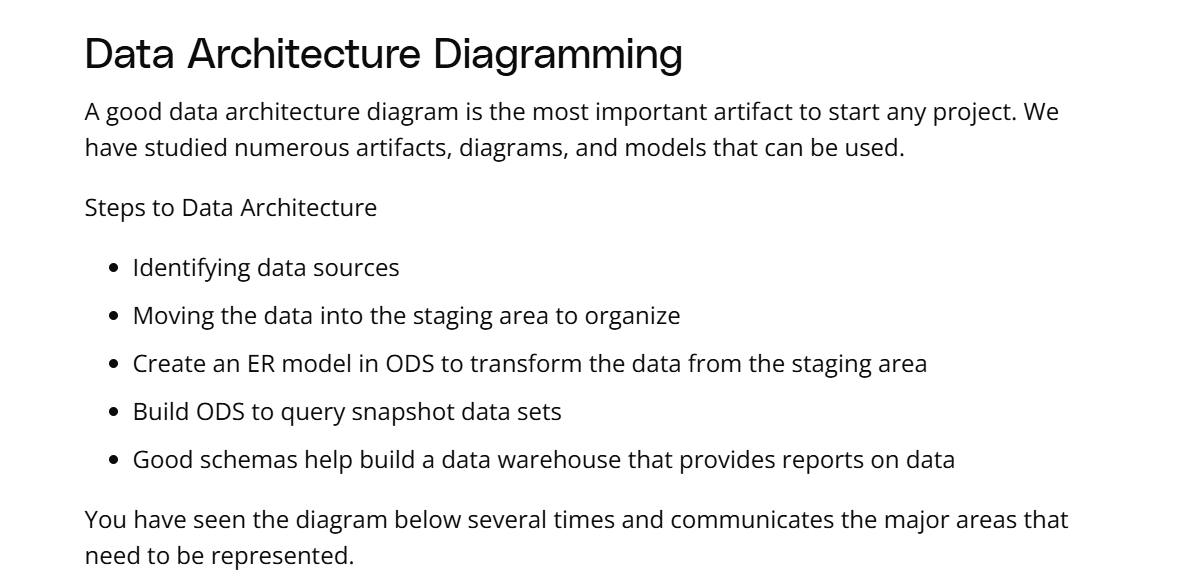

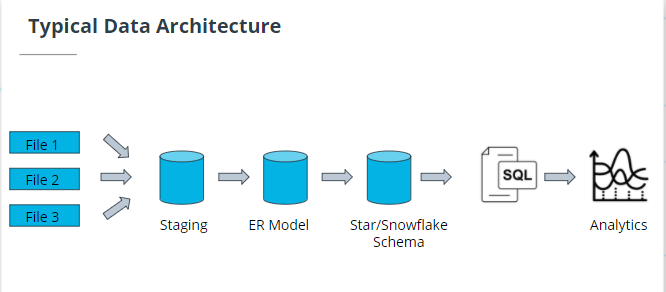

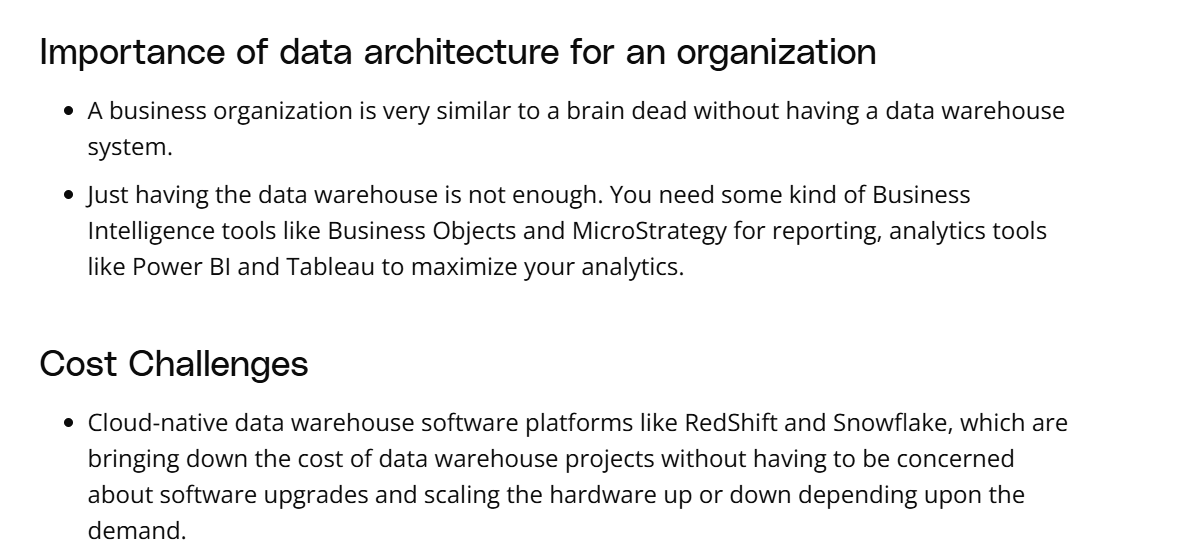

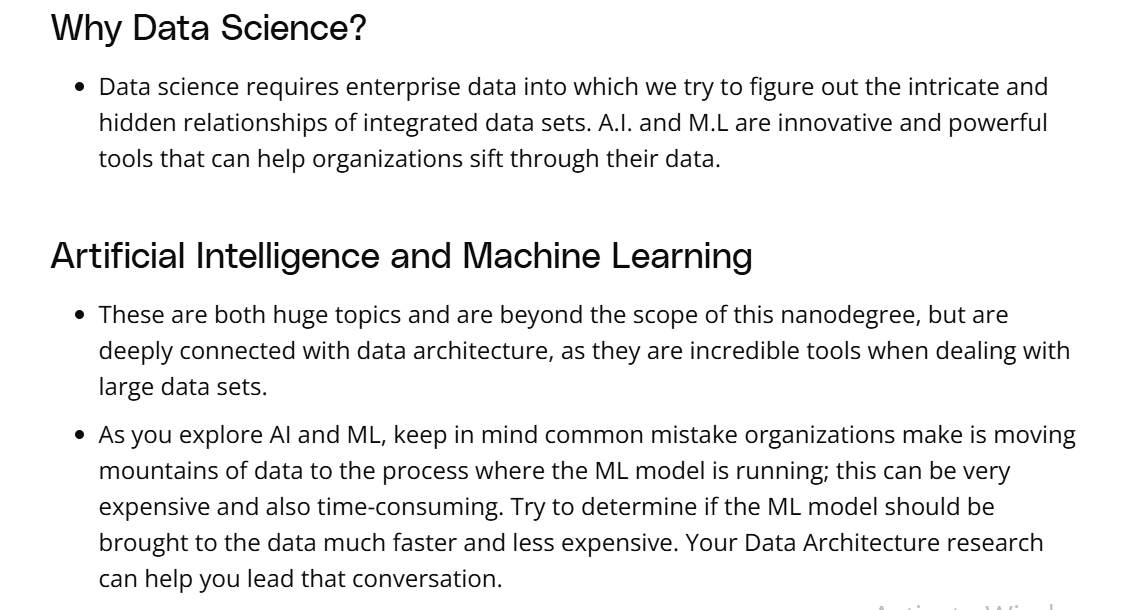

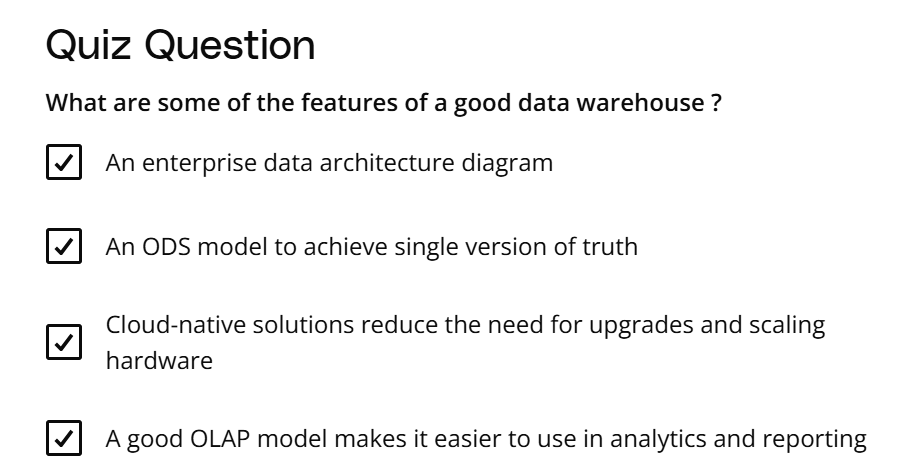

## Lesson Review

https://www.youtube.com/watch?v=HmiXGFejTqg

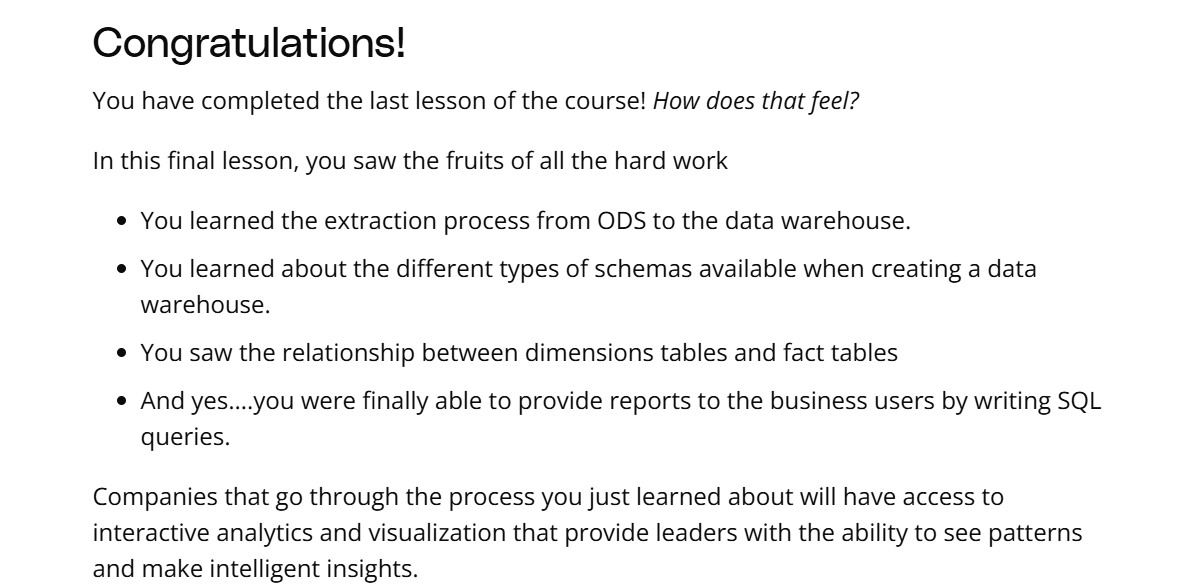

## Course Review and Conclusion

https://www.youtube.com/watch?v=n1PhCoJUSNk

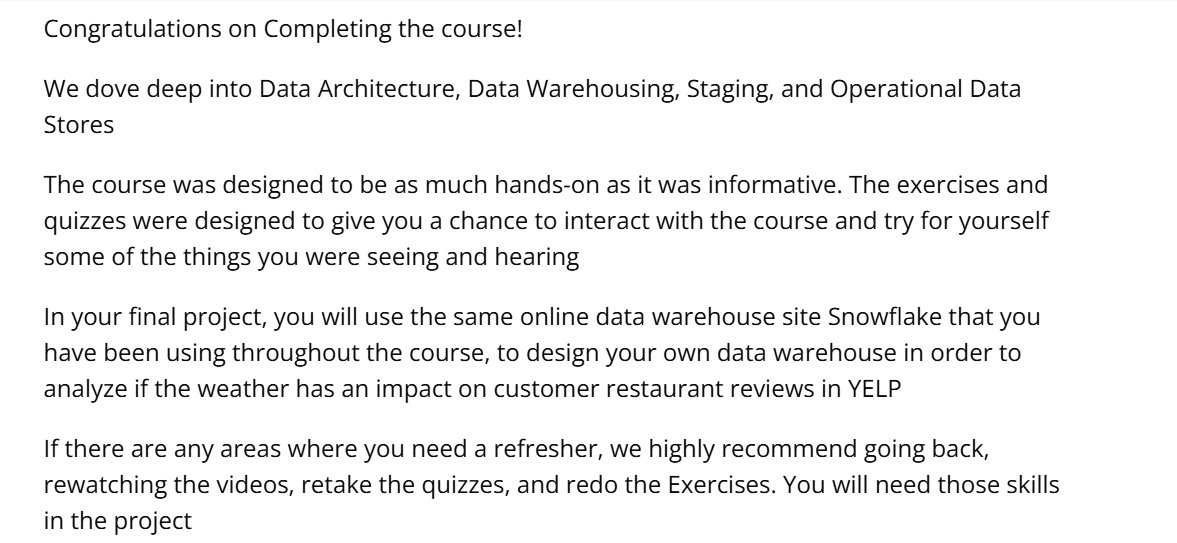

## Glossary

Accumulating Snapshot	Used to understand work-time studies of workflow steps to analyze time delays
Ad Hoc Queries	SQL database queries written dynamically as needed.
Bulk loading	Loading data in it's entirety into a table without having to go through one row at a time using ETL tools
Cloud-Native Tools	Building software taking advantage of unlimited cloud infrastructures, such as inexpensive on-demand computing and storage capacities
Columnar storage	Every column of the table runs as a separate thread and all columns run in parallel.
Conformed	A dimension, such as Date can be used for many fact tables without changing
Data Science	Extracting knowledge and patterns from various structured and unstructured data sets using scientific and statistical methods, processes, and algorithms
Data Warehouse	A central repository of integrated and cleaned data assets from one or more data sources for the purpose of reporting a single version of truth and data analysis.
Datamart	A smaller subset of the data warehouse to address a business group or a subject area
Degenerate	A primary key gives the meaning of the entire dimension without having to add any more attributes, hence the keys can be used in the fact table directly without having to create a dimension table
Denormalization	Tables that do not follow normalized rules and ER modeling relationships
Descriptive Analytics	Gives a reason for a question - What happened or what is happening
Dimension table	Tables that contain non-repetitive key values and their attributes. All dimension will have 1 to many relationships either with sub-dimension tables or Fact tables
Downstream Consumption	Interesting applications can be built when cleaned and integrated data sets are given for downstream consumption
Extraction	Pulling data from sources
Fact types	The three types are Transaction, Periodic and Accumulated
Historical Data Lineage	When every change, before and after values of every column, of a transaction is saved; this data being used for debugging the data anomalies or to find patterns.
Junk	Combination of different and unrelated attributes to avoid a large number of foreign keys in the fact table.
Operational reporting	Business operations need to know the cross-functional effectiveness of multiple integrated and cleaned transactional systems
Periodic Snapshot	A time window based snapshots can be used to collect data into data warehouse
Predictive Analytics	Takes historical data and feeds it into a machine learning model that considers key trends and patterns
Prescriptive Analytics	Business analysts and strategists come up with various courses of actions and the potential implications based on predictive analytics
RedShift	AWS cloud-native columnar storage data warehouse system built on top Postgress
Role playing	A dimension can play a different role depending upon the context.
Shrunken	Dimensions can be shrunk in order to aggregates and summaries. A quarter can be shrunk from months, months can be shrunk from dates.
Single Version of Truth	Some business terms and rules have multiple meanings when there is data dictionary. With a standard dictionary, business vocabulary can have a single version, hence data can have a single version, no matter who looks at it.
Snowflake schema	Modeling technique used for data warehousing
Snowflake schema	Elaborated technique to model complex OLAP system with many fact tables related (many to many with other fact tables and many to one with dimensional tables) much similar to ER model.
Star Schema	Fact table, which contain all details of transactions, is in the middle related (many to one) with many dimensional tables. Used to simplify OLAP complexity.
Static	Codes such as country or currency codes are static and do not change

## Additional Learning and Resources

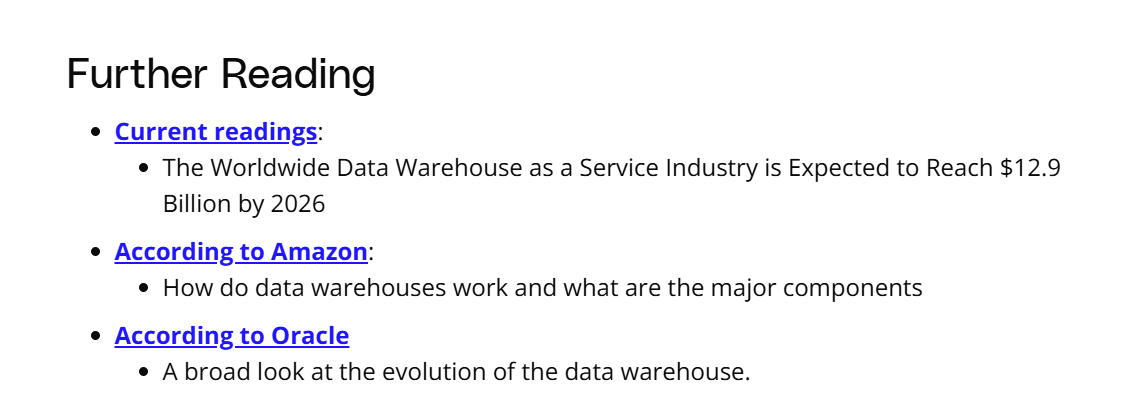

https://www.prnewswire.com/news-releases/the-worldwide-data-warehouse-as-a-service-industry-is-expected-to-reach-12-9-billion-by-2026--301362771.html

https://aws.amazon.com/data-warehouse/

https://www.oracle.com/database/what-is-a-data-warehouse/